# Understanding Machine Learning Metrics: A Visual Interactive Guide

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tsilva/aiml-notebooks/blob/main/notebooks/metrics-fundamentals.ipynb)

**Learn the difference between machine learning metrics through simple, visual, step-by-step examples.**

## Part 1: Introduction - Why Do We Need Metrics?

Imagine you've built a machine learning model. How do you know if it's any good?

**The Problem**: A model makes predictions, but we need a way to measure its performance.

**The Solution**: Metrics - numbers that tell us how well our model is doing.

### Learning Objectives

By the end of this notebook, you'll understand:
- What metrics are and why they matter
- The difference between **accuracy**, **precision**, **recall**, and **F1 score**
- When to use each metric
- The difference between **loss** (for training) and **metrics** (for evaluation)
- How to calculate metrics by hand and with code

Let's start with the simplest possible example!

## Part 2: Setup

First, let's import the libraries we'll need:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Set random seed for reproducibility
np.random.seed(42)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


Let's create some helper functions for visualization:

In [2]:
def plot_predictions(actual, predicted, labels=['Not Spam', 'Spam']):
    """Visualize predictions vs actual labels"""
    fig, ax = plt.subplots(1, 1, figsize=(12, 3))
    
    x = np.arange(len(actual))
    width = 0.35
    
    colors_actual = ['lightgreen' if a == 0 else 'lightcoral' for a in actual]
    colors_pred = ['green' if (a == p) else 'red' for a, p in zip(actual, predicted)]
    
    ax.bar(x - width/2, actual, width, label='Actual', color=colors_actual, edgecolor='black')
    ax.bar(x + width/2, predicted, width, label='Predicted', color=colors_pred, edgecolor='black', alpha=0.7)
    
    ax.set_xlabel('Email #')
    ax.set_ylabel('Class')
    ax.set_title('Predictions vs Actual Labels (Green=Correct, Red=Incorrect)')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{i+1}' for i in x])
    ax.set_yticks([0, 1])
    ax.set_yticklabels(labels)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix_custom(cm, labels=['Not Spam', 'Spam']):
    """Plot a confusion matrix with annotations"""
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels,
                cbar_kws={'label': 'Count'}, ax=ax, annot_kws={'size': 16})
    
    ax.set_ylabel('Actual Label', fontsize=12)
    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

print("✓ Helper functions defined!")

✓ Helper functions defined!


## Part 3: The Simplest Example - Binary Classification

Let's start with the simplest type of problem: **binary classification**.

**Scenario**: You've built a spam email detector. For each email, it predicts:
- **0** = Not Spam (Negative class)
- **1** = Spam (Positive class)

Here are 10 emails. Let's see how our model did:

In [3]:
# Actual labels (ground truth)
actual = np.array([0, 1, 0, 0, 1, 1, 0, 1, 0, 1])

# Model's predictions
predicted = np.array([0, 1, 0, 1, 1, 0, 0, 1, 0, 1])

# Let's view this as a table
import pandas as pd

df = pd.DataFrame({
    'Email #': range(1, 11),
    'Actual': ['Not Spam' if x == 0 else 'Spam' for x in actual],
    'Predicted': ['Not Spam' if x == 0 else 'Spam' for x in predicted],
    'Correct?': ['✓' if a == p else '✗' for a, p in zip(actual, predicted)]
})

print(df.to_string(index=False))

 Email #   Actual Predicted Correct?
       1 Not Spam  Not Spam        ✓
       2     Spam      Spam        ✓
       3 Not Spam  Not Spam        ✓
       4 Not Spam      Spam        ✗
       5     Spam      Spam        ✓
       6     Spam  Not Spam        ✗
       7 Not Spam  Not Spam        ✓
       8     Spam      Spam        ✓
       9 Not Spam  Not Spam        ✓
      10     Spam      Spam        ✓


Let's visualize this:

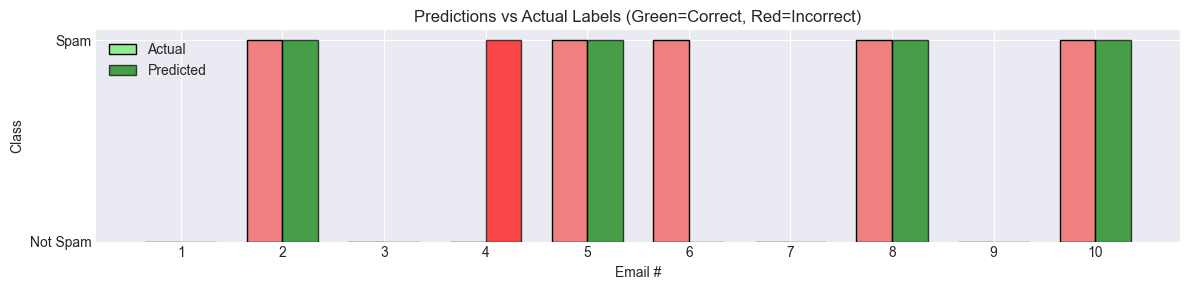

In [4]:
plot_predictions(actual, predicted)

**Question**: Looking at the chart, how many predictions did the model get right?

Count the green bars in the "Predicted" series. We'll calculate this precisely in the next section!

## Part 4: The Confusion Matrix - The Foundation

Before we can understand metrics, we need to understand the **confusion matrix**.

### What is a Confusion Matrix?

A confusion matrix breaks down our predictions into 4 categories:

| | Predicted: Not Spam | Predicted: Spam |
|---|---|---|
| **Actual: Not Spam** | True Negative (TN) | False Positive (FP) |
| **Actual: Spam** | False Negative (FN) | True Positive (TP) |

Let's break this down:

- **True Positive (TP)**: Model said "Spam" and it was actually spam ✓
- **True Negative (TN)**: Model said "Not Spam" and it was actually not spam ✓
- **False Positive (FP)**: Model said "Spam" but it was actually not spam ✗ (False alarm!)
- **False Negative (FN)**: Model said "Not Spam" but it was actually spam ✗ (Missed it!)

### Calculate by Hand

Let's count each category manually using our 10 emails:

In [5]:
# Let's count manually first
print("Let's examine each email:\n")

tp = fn = fp = tn = 0

for i in range(len(actual)):
    a = actual[i]
    p = predicted[i]
    
    actual_label = "Spam" if a == 1 else "Not Spam"
    pred_label = "Spam" if p == 1 else "Not Spam"
    
    # Determine category
    if a == 1 and p == 1:
        category = "TP (True Positive)"
        tp += 1
    elif a == 0 and p == 0:
        category = "TN (True Negative)"
        tn += 1
    elif a == 0 and p == 1:
        category = "FP (False Positive) - False Alarm!"
        fp += 1
    else:  # a == 1 and p == 0
        category = "FN (False Negative) - Missed it!"
        fn += 1
    
    print(f"Email {i+1}: Actual={actual_label}, Predicted={pred_label} → {category}")

print(f"\n{'='*60}")
print(f"Summary:")
print(f"  True Positives (TP):  {tp}")
print(f"  True Negatives (TN):  {tn}")
print(f"  False Positives (FP): {fp}")
print(f"  False Negatives (FN): {fn}")
print(f"{'='*60}")

Let's examine each email:

Email 1: Actual=Not Spam, Predicted=Not Spam → TN (True Negative)
Email 2: Actual=Spam, Predicted=Spam → TP (True Positive)
Email 3: Actual=Not Spam, Predicted=Not Spam → TN (True Negative)
Email 4: Actual=Not Spam, Predicted=Spam → FP (False Positive) - False Alarm!
Email 5: Actual=Spam, Predicted=Spam → TP (True Positive)
Email 6: Actual=Spam, Predicted=Not Spam → FN (False Negative) - Missed it!
Email 7: Actual=Not Spam, Predicted=Not Spam → TN (True Negative)
Email 8: Actual=Spam, Predicted=Spam → TP (True Positive)
Email 9: Actual=Not Spam, Predicted=Not Spam → TN (True Negative)
Email 10: Actual=Spam, Predicted=Spam → TP (True Positive)

Summary:
  True Positives (TP):  4
  True Negatives (TN):  4
  False Positives (FP): 1
  False Negatives (FN): 1


### Build the Confusion Matrix

In [6]:
# Create confusion matrix
cm = confusion_matrix(actual, predicted)

print("Confusion Matrix:")
print(cm)
print("\nReading the matrix:")
print(f"  Top-left (TN):     {cm[0, 0]} - Correctly predicted 'Not Spam'")
print(f"  Top-right (FP):    {cm[0, 1]} - Incorrectly predicted 'Spam' (false alarm)")
print(f"  Bottom-left (FN):  {cm[1, 0]} - Incorrectly predicted 'Not Spam' (missed spam)")
print(f"  Bottom-right (TP): {cm[1, 1]} - Correctly predicted 'Spam'")

Confusion Matrix:
[[4 1]
 [1 4]]

Reading the matrix:
  Top-left (TN):     4 - Correctly predicted 'Not Spam'
  Top-right (FP):    1 - Incorrectly predicted 'Spam' (false alarm)
  Bottom-left (FN):  1 - Incorrectly predicted 'Not Spam' (missed spam)
  Bottom-right (TP): 4 - Correctly predicted 'Spam'


### Visualize the Confusion Matrix

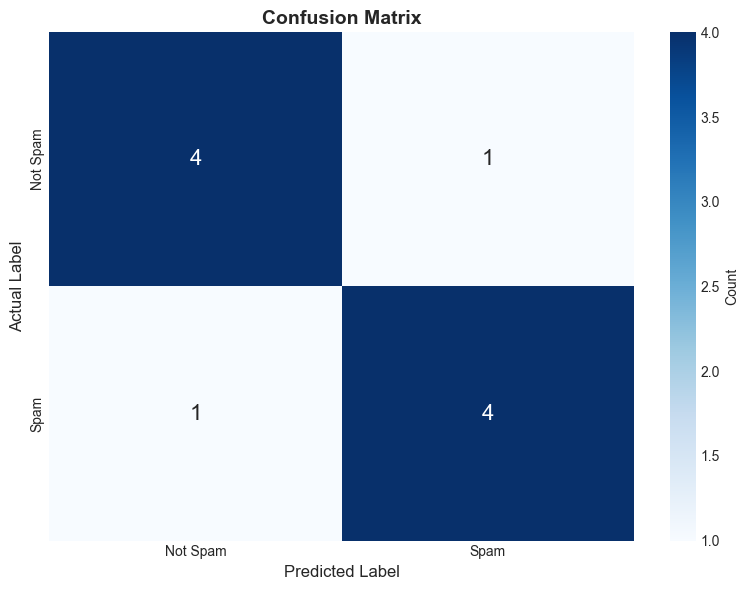

In [7]:
plot_confusion_matrix_custom(cm)

**Key Insight**: The confusion matrix is the foundation for all classification metrics!

From these 4 numbers (TP, TN, FP, FN), we can calculate accuracy, precision, recall, and F1 score.

## Part 5: Accuracy - The Most Intuitive Metric

### What is Accuracy?

Accuracy is the simplest metric. It answers the question:

**"What percentage of predictions were correct?"**

### Formula

$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

### Calculate by Hand

In [8]:
# From our confusion matrix:
tn, fp, fn, tp = cm.ravel()

print("Calculating Accuracy by Hand:\n")
print(f"Correct predictions (TP + TN): {tp} + {tn} = {tp + tn}")
print(f"Total predictions:             {tp + tn + fp + fn}")
print(f"\nAccuracy = {tp + tn} / {tp + tn + fp + fn} = {(tp + tn) / (tp + tn + fp + fn):.2f}")
print(f"\nIn other words: {(tp + tn) / (tp + tn + fp + fn) * 100:.1f}% of predictions were correct!")

Calculating Accuracy by Hand:

Correct predictions (TP + TN): 4 + 4 = 8
Total predictions:             10

Accuracy = 8 / 10 = 0.80

In other words: 80.0% of predictions were correct!


### Calculate with Code

In [9]:
# Method 1: Implement from scratch
def accuracy_from_scratch(y_true, y_pred):
    correct = np.sum(y_true == y_pred)
    total = len(y_true)
    return correct / total

accuracy_manual = accuracy_from_scratch(actual, predicted)
print(f"Accuracy (manual implementation): {accuracy_manual:.2f}")

# Method 2: Use sklearn
accuracy_sklearn = accuracy_score(actual, predicted)
print(f"Accuracy (sklearn):               {accuracy_sklearn:.2f}")

print(f"\nBoth methods give the same result: {accuracy_manual == accuracy_sklearn}")

Accuracy (manual implementation): 0.80
Accuracy (sklearn):               0.80

Both methods give the same result: True


### When Accuracy Works Well

Accuracy is great when:
- Classes are balanced (roughly equal number of each class)
- All mistakes are equally bad

### The Accuracy Paradox

But accuracy can be misleading! Let's see an example:

In [10]:
# Scenario: Cancer detection (1% of patients have cancer)
print("Scenario: Detecting a rare disease (1% of patients have it)\n")

# 1000 patients, 10 have cancer
n_patients = 1000
n_with_disease = 10

# A lazy model that always predicts "No disease"
actual_disease = np.array([0] * (n_patients - n_with_disease) + [1] * n_with_disease)
lazy_predictions = np.array([0] * n_patients)  # Always predicts "No disease"

lazy_accuracy = accuracy_score(actual_disease, lazy_predictions)

print(f"Lazy model (always predicts 'No disease'):")
print(f"  Accuracy: {lazy_accuracy:.1%}")
print(f"\nBut this model is useless! It never detects any actual disease cases.")
print(f"This is why we need other metrics!")

Scenario: Detecting a rare disease (1% of patients have it)

Lazy model (always predicts 'No disease'):
  Accuracy: 99.0%

But this model is useless! It never detects any actual disease cases.
This is why we need other metrics!


**Key Insight**: High accuracy doesn't always mean a good model, especially with imbalanced datasets!

## Part 6: Precision - "When I Say Yes, Am I Right?"

### What is Precision?

Precision answers the question:

**"When my model predicts the positive class, how often is it correct?"**

### Formula

$$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives + False Positives}} = \frac{TP}{TP + FP}$$

Another way to think about it:

$$\text{Precision} = \frac{\text{Correct Positive Predictions}}{\text{All Positive Predictions}}$$

### Real-World Analogy

**Email Spam Filter**: You want high precision because **false positives are annoying**.

If the filter marks a legitimate email as spam (FP), you might miss an important message!

High precision means: "When the filter says 'spam', it's usually right."

### Calculate by Hand

In [11]:
# Using our confusion matrix values
print("Calculating Precision by Hand:\n")
print(f"True Positives (TP):  {tp} (correctly predicted 'Spam')")
print(f"False Positives (FP): {fp} (incorrectly predicted 'Spam')")
print(f"\nAll positive predictions: {tp} + {fp} = {tp + fp}")
print(f"Correct positive predictions: {tp}")
print(f"\nPrecision = {tp} / {tp + fp} = {tp / (tp + fp):.2f}")
print(f"\nIn other words: {tp / (tp + fp) * 100:.1f}% of 'Spam' predictions were correct!")

Calculating Precision by Hand:

True Positives (TP):  4 (correctly predicted 'Spam')
False Positives (FP): 1 (incorrectly predicted 'Spam')

All positive predictions: 4 + 1 = 5
Correct positive predictions: 4

Precision = 4 / 5 = 0.80

In other words: 80.0% of 'Spam' predictions were correct!


### Calculate with Code

In [12]:
# Method 1: Implement from scratch
def precision_from_scratch(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    if tp + fp == 0:
        return 0.0
    return tp / (tp + fp)

precision_manual = precision_from_scratch(actual, predicted)
print(f"Precision (manual implementation): {precision_manual:.2f}")

# Method 2: Use sklearn
precision_sklearn = precision_score(actual, predicted)
print(f"Precision (sklearn):               {precision_sklearn:.2f}")

Precision (manual implementation): 0.80
Precision (sklearn):               0.80


### Visualize What Precision Measures

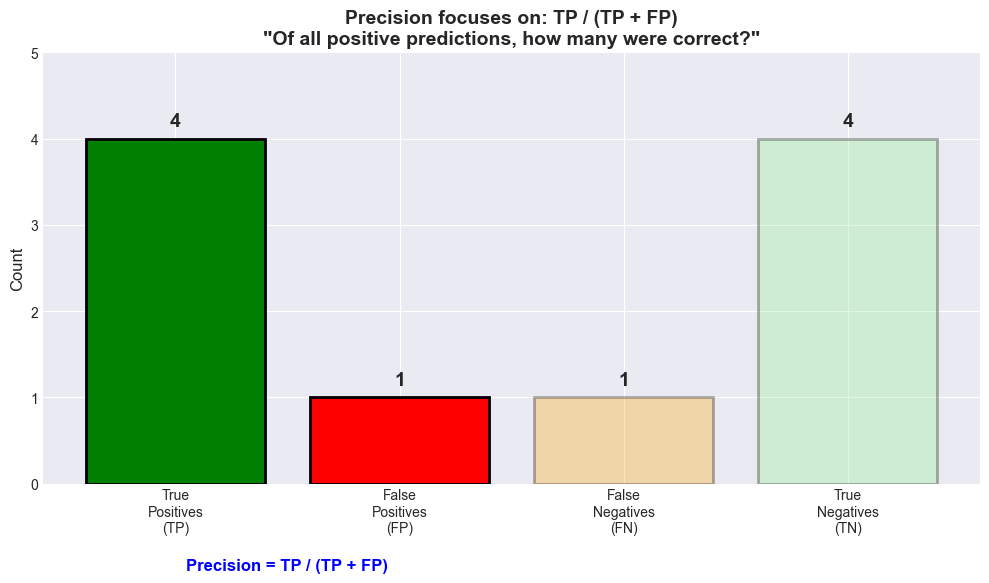

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

# Create a visual representation
categories = ['True\nPositives\n(TP)', 'False\nPositives\n(FP)', 'False\nNegatives\n(FN)', 'True\nNegatives\n(TN)']
values = [tp, fp, fn, tn]
colors = ['green', 'red', 'orange', 'lightgreen']

bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=2)

# Highlight TP and FP (used in precision)
bars[0].set_alpha(1.0)
bars[1].set_alpha(1.0)
bars[2].set_alpha(0.3)
bars[3].set_alpha(0.3)

ax.set_ylabel('Count', fontsize=12)
ax.set_title('Precision focuses on: TP / (TP + FP)\n"Of all positive predictions, how many were correct?"', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(values) + 1)

# Add values on bars
for i, (bar, val) in enumerate(zip(bars, values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{val}', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Add annotation
ax.annotate('', xy=(0, -0.5), xytext=(1, -0.5),
            arrowprops=dict(arrowstyle='<->', color='blue', lw=2))
ax.text(0.5, -1, 'Precision = TP / (TP + FP)', ha='center', fontsize=12, color='blue', fontweight='bold')

plt.tight_layout()
plt.show()

### When to Prioritize Precision

Focus on precision when **false positives are costly**:

- Email spam filters (missing important emails)
- Video recommendations (showing irrelevant videos wastes time)
- Product recommendations (recommending wrong products frustrates users)
- Legal document classification (false accusations)

## Part 7: Recall - "Did I Find All the Positives?"

### What is Recall?

Recall (also called **Sensitivity** or **True Positive Rate**) answers:

**"Of all actual positive cases, how many did my model find?"**

### Formula

$$\text{Recall} = \frac{\text{True Positives}}{\text{True Positives + False Negatives}} = \frac{TP}{TP + FN}$$

Another way to think about it:

$$\text{Recall} = \frac{\text{Correctly Identified Positives}}{\text{All Actual Positives}}$$

### Real-World Analogy

**Cancer Detection**: You want high recall because **false negatives are dangerous**.

If the test misses cancer (FN), the patient doesn't get treatment!

High recall means: "The test catches almost all cancer cases."

### Calculate by Hand

In [14]:
# Using our confusion matrix values
print("Calculating Recall by Hand:\n")
print(f"True Positives (TP):  {tp} (correctly identified spam)")
print(f"False Negatives (FN): {fn} (missed spam - predicted 'Not Spam' but was spam)")
print(f"\nAll actual positives: {tp} + {fn} = {tp + fn}")
print(f"Correctly identified positives: {tp}")
print(f"\nRecall = {tp} / {tp + fn} = {tp / (tp + fn):.2f}")
print(f"\nIn other words: We caught {tp / (tp + fn) * 100:.1f}% of all actual spam!")

Calculating Recall by Hand:

True Positives (TP):  4 (correctly identified spam)
False Negatives (FN): 1 (missed spam - predicted 'Not Spam' but was spam)

All actual positives: 4 + 1 = 5
Correctly identified positives: 4

Recall = 4 / 5 = 0.80

In other words: We caught 80.0% of all actual spam!


### Calculate with Code

In [15]:
# Method 1: Implement from scratch
def recall_from_scratch(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    if tp + fn == 0:
        return 0.0
    return tp / (tp + fn)

recall_manual = recall_from_scratch(actual, predicted)
print(f"Recall (manual implementation): {recall_manual:.2f}")

# Method 2: Use sklearn
recall_sklearn = recall_score(actual, predicted)
print(f"Recall (sklearn):               {recall_sklearn:.2f}")

Recall (manual implementation): 0.80
Recall (sklearn):               0.80


### Visualize What Recall Measures

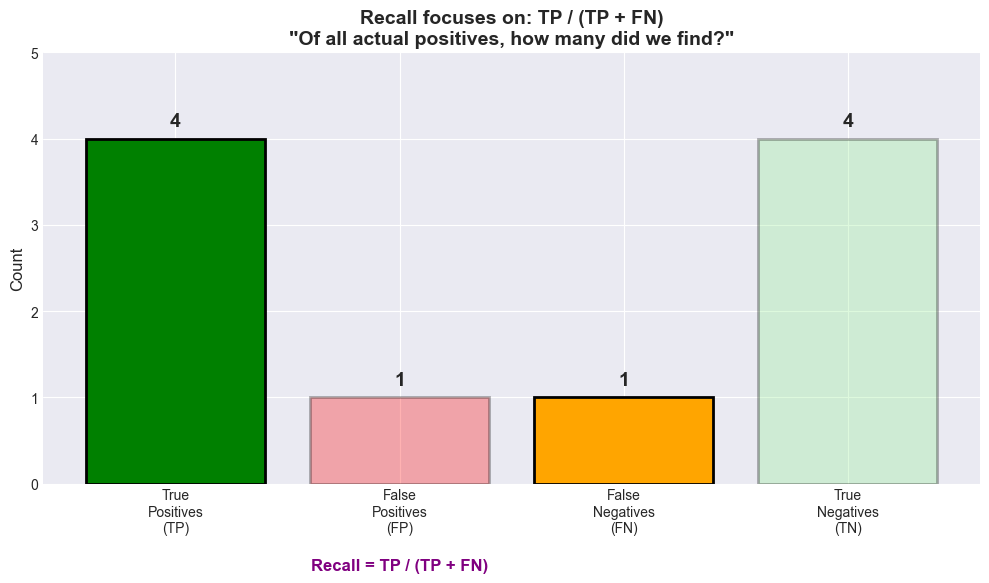

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['True\nPositives\n(TP)', 'False\nPositives\n(FP)', 'False\nNegatives\n(FN)', 'True\nNegatives\n(TN)']
values = [tp, fp, fn, tn]
colors = ['green', 'red', 'orange', 'lightgreen']

bars = ax.bar(categories, values, color=colors, edgecolor='black', linewidth=2)

# Highlight TP and FN (used in recall)
bars[0].set_alpha(1.0)
bars[1].set_alpha(0.3)
bars[2].set_alpha(1.0)
bars[3].set_alpha(0.3)

ax.set_ylabel('Count', fontsize=12)
ax.set_title('Recall focuses on: TP / (TP + FN)\n"Of all actual positives, how many did we find?"', 
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(values) + 1)

# Add values on bars
for i, (bar, val) in enumerate(zip(bars, values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{val}', ha='center', va='bottom', fontsize=14, fontweight='bold')

# Add annotation
ax.annotate('', xy=(0, -0.5), xytext=(2, -0.5),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=2))
ax.text(1, -1, 'Recall = TP / (TP + FN)', ha='center', fontsize=12, color='purple', fontweight='bold')

plt.tight_layout()
plt.show()

### When to Prioritize Recall

Focus on recall when **false negatives are costly**:

- Medical diagnosis (missing diseases)
- Fraud detection (missing fraudulent transactions)
- Security systems (missing threats)
- Search engines (missing relevant results)

## Part 8: The Precision-Recall Tradeoff

### Why Are They Inversely Related?

Here's the key insight: **You can't maximize both precision and recall at the same time!**

- **Higher recall** → Predict positive more often → More false positives → Lower precision
- **Higher precision** → Predict positive less often → More false negatives → Lower recall

Let's see this in action:

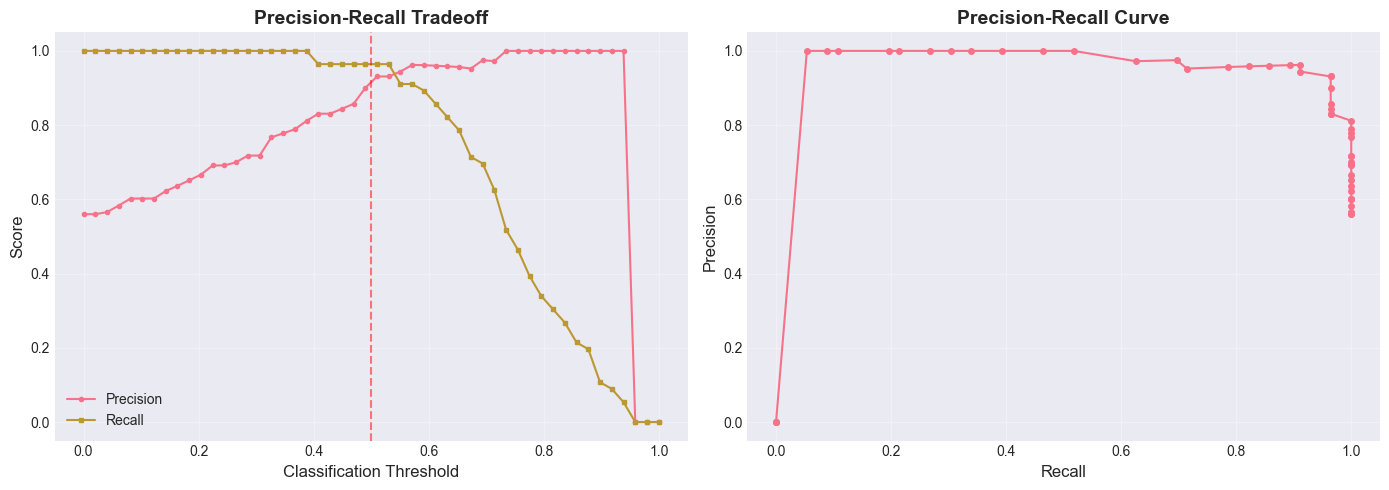

Notice how as recall increases (left plot), precision tends to decrease!


In [17]:
# Simulate a model with confidence scores
np.random.seed(42)

# Generate some true labels and predicted probabilities
n_samples = 100
y_true = np.random.randint(0, 2, n_samples)

# Predicted probabilities (model's confidence)
y_proba = np.where(y_true == 1, 
                   np.random.beta(5, 2, n_samples),  # Higher for actual positives
                   np.random.beta(2, 5, n_samples))  # Lower for actual negatives

# Try different thresholds
thresholds = np.linspace(0, 1, 50)
precisions = []
recalls = []

for threshold in thresholds:
    y_pred = (y_proba >= threshold).astype(int)
    
    if np.sum(y_pred) > 0:  # At least one positive prediction
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        precisions.append(prec)
        recalls.append(rec)
    else:
        precisions.append(0)
        recalls.append(0)

# Plot precision-recall curve
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Precision and Recall vs Threshold
ax1.plot(thresholds, precisions, label='Precision', marker='o', markersize=3)
ax1.plot(thresholds, recalls, label='Recall', marker='s', markersize=3)
ax1.set_xlabel('Classification Threshold', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Precision-Recall Tradeoff', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.axvline(0.5, color='red', linestyle='--', alpha=0.5, label='Default threshold')

# Right plot: Precision vs Recall
ax2.plot(recalls, precisions, marker='o', markersize=4)
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Notice how as recall increases (left plot), precision tends to decrease!")

### Choosing the Right Balance

The tradeoff depends on your application:

| Scenario | Prioritize | Why? |
|---|---|---|
| Email spam filter | **Precision** | False positives annoy users |
| Cancer screening | **Recall** | Missing cases is life-threatening |
| Fraud detection | **Recall** | Missing fraud costs money |
| Video recommendations | **Precision** | Bad recommendations waste time |

### Reflection Question

**Which metric would you prioritize for a self-driving car detecting pedestrians?**

Think about it, then run the next cell for the answer:

In [18]:
print("Answer: RECALL!")
print("\nWhy?")
print("- False Negative (FN): Missing a pedestrian = DISASTER (accident!)")
print("- False Positive (FP): Detecting phantom pedestrian = Minor issue (car slows down unnecessarily)")
print("\nIn safety-critical systems, we must minimize false negatives at all costs.")

Answer: RECALL!

Why?
- False Negative (FN): Missing a pedestrian = DISASTER (accident!)
- False Positive (FP): Detecting phantom pedestrian = Minor issue (car slows down unnecessarily)

In safety-critical systems, we must minimize false negatives at all costs.


## Part 9: F1 Score - The Harmonic Mean

### What is F1 Score?

What if you want to balance precision and recall?

The **F1 score** is the **harmonic mean** of precision and recall.

### Formula

$$F1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

Or equivalently:

$$F1 = \frac{2 \cdot TP}{2 \cdot TP + FP + FN}$$

### Why Harmonic Mean?

The harmonic mean punishes extreme values. Let's compare:

In [19]:
# Example: Two scenarios
scenarios = [
    {"name": "Balanced", "precision": 0.8, "recall": 0.8},
    {"name": "Unbalanced", "precision": 0.9, "recall": 0.3},
]

print("Comparing Arithmetic Mean vs Harmonic Mean:\n")
print(f"{'Scenario':<12} {'Precision':<10} {'Recall':<10} {'Arithmetic':<12} {'Harmonic (F1)':<12}")
print("="*60)

for s in scenarios:
    p, r = s['precision'], s['recall']
    arithmetic = (p + r) / 2
    harmonic = 2 * (p * r) / (p + r)
    print(f"{s['name']:<12} {p:<10.2f} {r:<10.2f} {arithmetic:<12.2f} {harmonic:<12.2f}")

print("\nNotice: The harmonic mean is lower for the unbalanced scenario!")
print("This is good - it encourages balancing both metrics.")

Comparing Arithmetic Mean vs Harmonic Mean:

Scenario     Precision  Recall     Arithmetic   Harmonic (F1)
Balanced     0.80       0.80       0.80         0.80        
Unbalanced   0.90       0.30       0.60         0.45        

Notice: The harmonic mean is lower for the unbalanced scenario!
This is good - it encourages balancing both metrics.


### Calculate by Hand

In [20]:
# Calculate precision and recall first
prec = tp / (tp + fp)
rec = tp / (tp + fn)

print("Calculating F1 Score by Hand:\n")
print(f"Precision: {prec:.2f}")
print(f"Recall:    {rec:.2f}")
print(f"\nF1 = 2 × (Precision × Recall) / (Precision + Recall)")
print(f"   = 2 × ({prec:.2f} × {rec:.2f}) / ({prec:.2f} + {rec:.2f})")
print(f"   = 2 × {prec * rec:.2f} / {prec + rec:.2f}")
print(f"   = {2 * prec * rec:.2f} / {prec + rec:.2f}")
print(f"   = {2 * (prec * rec) / (prec + rec):.2f}")

Calculating F1 Score by Hand:

Precision: 0.80
Recall:    0.80

F1 = 2 × (Precision × Recall) / (Precision + Recall)
   = 2 × (0.80 × 0.80) / (0.80 + 0.80)
   = 2 × 0.64 / 1.60
   = 1.28 / 1.60
   = 0.80


### Calculate with Code

In [21]:
# Method 1: Implement from scratch
def f1_from_scratch(y_true, y_pred):
    prec = precision_from_scratch(y_true, y_pred)
    rec = recall_from_scratch(y_true, y_pred)
    if prec + rec == 0:
        return 0.0
    return 2 * (prec * rec) / (prec + rec)

f1_manual = f1_from_scratch(actual, predicted)
print(f"F1 Score (manual implementation): {f1_manual:.2f}")

# Method 2: Use sklearn
f1_sklearn = f1_score(actual, predicted)
print(f"F1 Score (sklearn):               {f1_sklearn:.2f}")

F1 Score (manual implementation): 0.80
F1 Score (sklearn):               0.80


### When F1 is Useful

Use F1 when:
- You want to balance precision and recall
- Both false positives and false negatives matter
- You need a single number to compare models
- Classes are imbalanced (F1 is better than accuracy)

### F-Beta Scores: Adjusting the Balance

Sometimes you want to favor precision or recall more. Use **F-beta**:

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \cdot \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

- **β = 1**: F1 score (equal weight)
- **β = 0.5**: Favors precision
- **β = 2**: Favors recall

In [22]:
from sklearn.metrics import fbeta_score

f05 = fbeta_score(actual, predicted, beta=0.5)
f1 = fbeta_score(actual, predicted, beta=1.0)
f2 = fbeta_score(actual, predicted, beta=2.0)

print(f"F0.5 (favors precision): {f05:.2f}")
print(f"F1   (balanced):         {f1:.2f}")
print(f"F2   (favors recall):    {f2:.2f}")

F0.5 (favors precision): 0.80
F1   (balanced):         0.80
F2   (favors recall):    0.80


## Part 10: Loss vs Metrics - What's the Difference?

This is a crucial distinction that confuses many beginners!

### Loss Functions

- **Purpose**: Used during **training** to optimize the model
- **Examples**: Cross-entropy loss, MSE (Mean Squared Error)
- **Key property**: Must be **differentiable** (so we can compute gradients)
- **Goal**: Minimize loss

### Metrics

- **Purpose**: Used for **evaluation** to understand model performance
- **Examples**: Accuracy, F1, Precision, Recall
- **Key property**: Often **not differentiable** (e.g., accuracy is discrete)
- **Goal**: Interpret and compare models

### Why Can't We Use Metrics for Training?

Let's see why accuracy isn't differentiable:

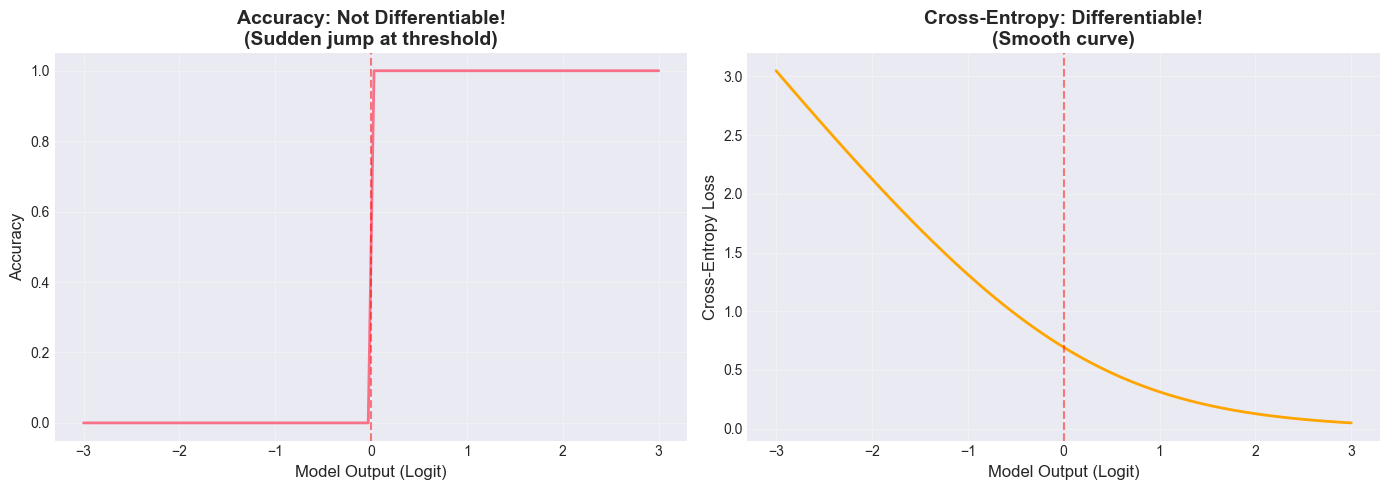

Key Insight: Gradient descent needs smooth, differentiable functions!
That's why we use loss functions (like cross-entropy) for training.


In [23]:
# Simulate model outputs (logits) and how they change during training
logits = np.linspace(-3, 3, 100)
predictions = (logits > 0).astype(int)  # Convert to class predictions

# True label is 1
true_label = 1

# Accuracy: 0 if wrong, 1 if correct (not differentiable!)
accuracy_values = (predictions == true_label).astype(int)

# Cross-entropy loss (differentiable!)
probs = 1 / (1 + np.exp(-logits))  # Sigmoid
ce_loss = -np.log(probs + 1e-10)  # Cross-entropy

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot accuracy
ax1.plot(logits, accuracy_values, linewidth=2)
ax1.set_xlabel('Model Output (Logit)', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Accuracy: Not Differentiable!\n(Sudden jump at threshold)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.axvline(0, color='red', linestyle='--', alpha=0.5)

# Plot cross-entropy loss
ax2.plot(logits, ce_loss, linewidth=2, color='orange')
ax2.set_xlabel('Model Output (Logit)', fontsize=12)
ax2.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax2.set_title('Cross-Entropy: Differentiable!\n(Smooth curve)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.axvline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("Key Insight: Gradient descent needs smooth, differentiable functions!")
print("That's why we use loss functions (like cross-entropy) for training.")

### The Training-Evaluation Loop

Here's how loss and metrics work together:

```
1. Training:
   - Forward pass → Calculate loss (e.g., cross-entropy)
   - Backward pass → Compute gradients
   - Update weights → Minimize loss

2. Evaluation:
   - Calculate metrics (accuracy, F1, etc.)
   - Interpret model performance
   - Compare models
```

### Visualize Loss vs Metrics During Training

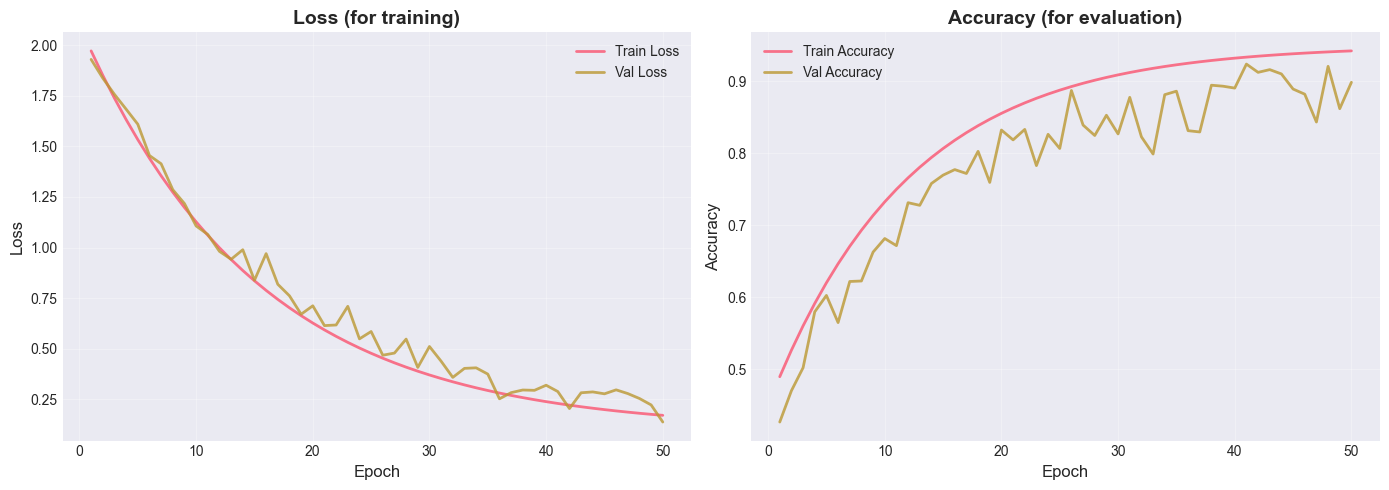

Typical training curve:
  - Loss decreases (we're optimizing this)
  - Accuracy increases (we're monitoring this)


In [24]:
# Simulate training curves
epochs = np.arange(1, 51)

# Loss decreases smoothly
train_loss = 2.0 * np.exp(-epochs / 15) + 0.1
val_loss = 2.0 * np.exp(-epochs / 15) + 0.15 + 0.05 * np.random.randn(len(epochs))

# Accuracy increases (but not as smoothly)
train_acc = 1 - (0.5 * np.exp(-epochs / 12) + 0.05)
val_acc = 1 - (0.5 * np.exp(-epochs / 12) + 0.1 + 0.03 * np.random.randn(len(epochs)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot loss
ax1.plot(epochs, train_loss, label='Train Loss', linewidth=2)
ax1.plot(epochs, val_loss, label='Val Loss', linewidth=2, alpha=0.8)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Loss (for training)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot accuracy
ax2.plot(epochs, train_acc, label='Train Accuracy', linewidth=2)
ax2.plot(epochs, val_acc, label='Val Accuracy', linewidth=2, alpha=0.8)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Accuracy (for evaluation)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Typical training curve:")
print("  - Loss decreases (we're optimizing this)")
print("  - Accuracy increases (we're monitoring this)")

### Common Loss Functions

| Task | Loss Function | When to Use |
|---|---|---|
| Binary Classification | Binary Cross-Entropy | Two classes (0 or 1) |
| Multi-Class Classification | Categorical Cross-Entropy | Multiple classes (one-hot encoded) |
| Regression | MSE (Mean Squared Error) | Predicting continuous values |
| Regression | MAE (Mean Absolute Error) | Robust to outliers |

## Part 11: Multi-Class Classification

So far we've looked at binary classification (2 classes). What about more classes?

Let's look at an example with 3 classes:

Multi-Class Confusion Matrix:

      Cat  Dog  Bird
Cat     3    1     0
Dog     0    2     1
Bird    0    0     3


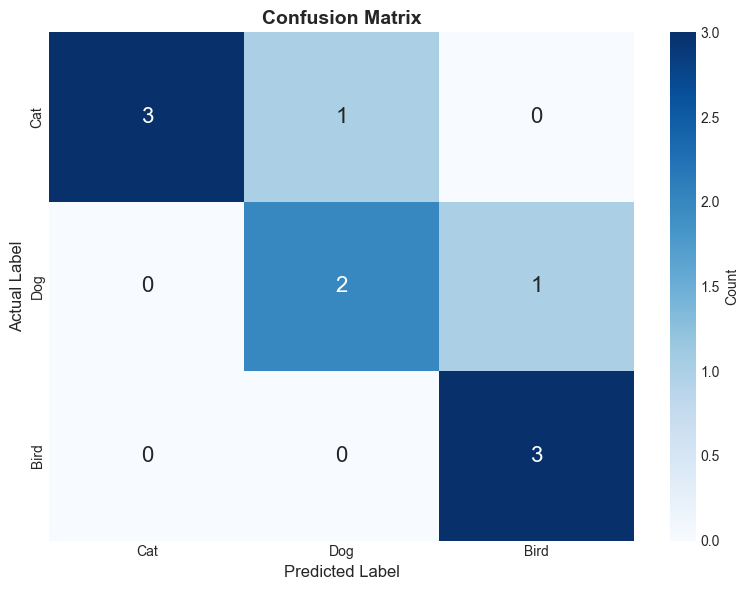

In [25]:
# Example: Image classification (Cat, Dog, Bird)
y_true_multi = np.array([0, 1, 2, 0, 1, 2, 0, 1, 2, 0])
y_pred_multi = np.array([0, 1, 2, 0, 2, 2, 1, 1, 2, 0])

class_names = ['Cat', 'Dog', 'Bird']

# Confusion matrix
cm_multi = confusion_matrix(y_true_multi, y_pred_multi)

print("Multi-Class Confusion Matrix:\n")
print(pd.DataFrame(cm_multi, index=class_names, columns=class_names))

# Visualize
plot_confusion_matrix_custom(cm_multi, labels=class_names)

## Part 11.5: Averaging Strategies - The Key to Multi-Class Metrics

When we have multiple classes, we have 3 different ways to combine per-class metrics into a single number:

### The Three Averaging Methods

1. **Macro Average**: Simple average of per-class metrics
   - Formula: `(Metric_Class1 + Metric_Class2 + Metric_Class3) / 3`
   - **Treats all classes equally** (regardless of class size)
   - Use when: All classes are equally important

2. **Micro Average**: Calculate metrics globally by counting total TP, FP, FN
   - Formula: Calculate one confusion matrix for all classes, then compute metrics
   - **Treats all samples equally** (larger classes have more weight)
   - Use when: You care about overall accuracy across all predictions

3. **Weighted Average**: Weight per-class metrics by number of samples
   - Formula: `Σ (Metric_Class_i × Support_i) / Total_Samples`
   - **Balances between macro and micro** (accounts for class imbalance)
   - Use when: You want to balance class importance with class frequency

Let's see these in action with concrete examples!

In [26]:
# Let's manually calculate all three averaging methods for precision

# Step 1: Get per-class precision (from sklearn for verification)
from sklearn.metrics import precision_score, recall_score

precision_per_class = precision_score(y_true_multi, y_pred_multi, average=None)
support_per_class = np.bincount(y_true_multi)

print("Step-by-Step Averaging Demonstration")
print("="*70)
print("\nPer-Class Metrics:")
for i, (prec, supp) in enumerate(zip(precision_per_class, support_per_class)):
    print(f"  {class_names[i]}: Precision = {prec:.3f}, Support = {supp} samples")

# MACRO AVERAGE: Simple average
print("\n" + "-"*70)
print("1. MACRO AVERAGE (Simple Average):")
print("   Formula: (P_cat + P_dog + P_bird) / 3")
macro_manual = np.mean(precision_per_class)
print(f"   Calculation: ({precision_per_class[0]:.3f} + {precision_per_class[1]:.3f} + {precision_per_class[2]:.3f}) / 3")
print(f"   Result: {macro_manual:.3f}")
print(f"   ✓ Verified: {precision_score(y_true_multi, y_pred_multi, average='macro'):.3f}")
print("\n   Interpretation: Each class contributes equally, regardless of size")

# WEIGHTED AVERAGE: Weight by support
print("\n" + "-"*70)
print("2. WEIGHTED AVERAGE (Weight by Class Frequency):")
print("   Formula: Σ(Precision_i × Support_i) / Total_Samples")
weighted_manual = np.sum(precision_per_class * support_per_class) / np.sum(support_per_class)
print(f"   Calculation: ({precision_per_class[0]:.3f}×{support_per_class[0]} + " +
      f"{precision_per_class[1]:.3f}×{support_per_class[1]} + " +
      f"{precision_per_class[2]:.3f}×{support_per_class[2]}) / {np.sum(support_per_class)}")
print(f"   Result: {weighted_manual:.3f}")
print(f"   ✓ Verified: {precision_score(y_true_multi, y_pred_multi, average='weighted'):.3f}")
print("\n   Interpretation: Larger classes have more influence")

# MICRO AVERAGE: Global calculation
print("\n" + "-"*70)
print("3. MICRO AVERAGE (Global TP, FP, FN):")
print("   Formula: Total_TP / (Total_TP + Total_FP)")

# Calculate total TP and FP across all classes
total_tp = np.sum(np.diag(cm_multi))  # Sum of diagonal
total_fp = np.sum(cm_multi) - total_tp  # Everything else is FP+FN

# For multiclass, micro precision = accuracy
micro_manual = total_tp / np.sum(cm_multi)
print(f"   Total TP (correct predictions): {total_tp}")
print(f"   Total samples: {np.sum(cm_multi)}")
print(f"   Result: {total_tp} / {np.sum(cm_multi)} = {micro_manual:.3f}")
print(f"   ✓ Verified: {precision_score(y_true_multi, y_pred_multi, average='micro'):.3f}")
print("\n   Interpretation: Overall accuracy across all predictions")
print("   Note: For multiclass, micro avg precision = recall = F1 = accuracy!")

print("\n" + "="*70)
print("\nSummary:")
print(f"  Macro avg:    {macro_manual:.3f} - All classes equal weight")
print(f"  Weighted avg: {weighted_manual:.3f} - Classes weighted by frequency")  
print(f"  Micro avg:    {micro_manual:.3f} - Overall accuracy")

Step-by-Step Averaging Demonstration

Per-Class Metrics:
  Cat: Precision = 1.000, Support = 4 samples
  Dog: Precision = 0.667, Support = 3 samples
  Bird: Precision = 0.750, Support = 3 samples

----------------------------------------------------------------------
1. MACRO AVERAGE (Simple Average):
   Formula: (P_cat + P_dog + P_bird) / 3
   Calculation: (1.000 + 0.667 + 0.750) / 3
   Result: 0.806
   ✓ Verified: 0.806

   Interpretation: Each class contributes equally, regardless of size

----------------------------------------------------------------------
2. WEIGHTED AVERAGE (Weight by Class Frequency):
   Formula: Σ(Precision_i × Support_i) / Total_Samples
   Calculation: (1.000×4 + 0.667×3 + 0.750×3) / 10
   Result: 0.825
   ✓ Verified: 0.825

   Interpretation: Larger classes have more influence

----------------------------------------------------------------------
3. MICRO AVERAGE (Global TP, FP, FN):
   Formula: Total_TP / (Total_TP + Total_FP)
   Total TP (correct predict

### Visualizing the Differences

Let's create a visual comparison to see how these averaging methods differ:

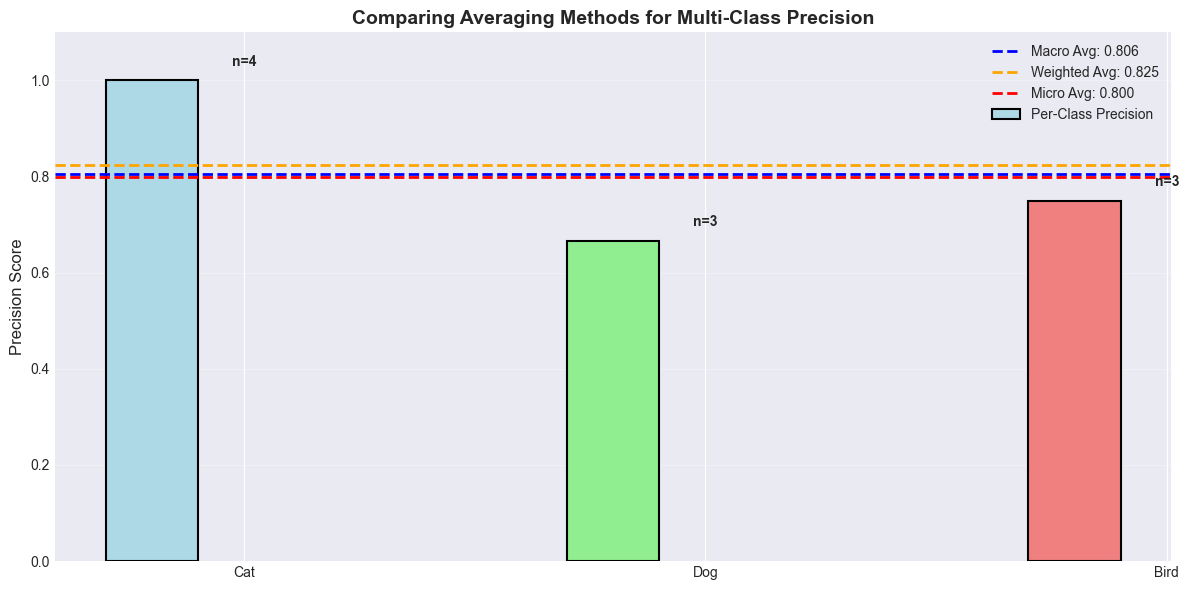


Notice: In this balanced example, all three averages are similar.
Let's see what happens with an IMBALANCED dataset...


In [27]:
# Create visualization comparing averaging methods
fig, ax = plt.subplots(figsize=(12, 6))

# Data for visualization
x_pos = np.arange(len(class_names))
width = 0.2

# Per-class precision
bars1 = ax.bar(x_pos - width, precision_per_class, width, label='Per-Class Precision', 
               color=['lightblue', 'lightgreen', 'lightcoral'], edgecolor='black', linewidth=1.5)

# Add horizontal lines for averages
ax.axhline(y=macro_manual, color='blue', linestyle='--', linewidth=2, label=f'Macro Avg: {macro_manual:.3f}')
ax.axhline(y=weighted_manual, color='orange', linestyle='--', linewidth=2, label=f'Weighted Avg: {weighted_manual:.3f}')
ax.axhline(y=micro_manual, color='red', linestyle='--', linewidth=2, label=f'Micro Avg: {micro_manual:.3f}')

# Styling
ax.set_ylabel('Precision Score', fontsize=12)
ax.set_title('Comparing Averaging Methods for Multi-Class Precision', fontsize=14, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names)
ax.legend(loc='best')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')

# Add support annotations
for i, (prec, supp) in enumerate(zip(precision_per_class, support_per_class)):
    ax.text(i, prec + 0.03, f'n={supp}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nNotice: In this balanced example, all three averages are similar.")
print("Let's see what happens with an IMBALANCED dataset...")

### Example with Imbalanced Classes

This is where averaging methods **really** matter! Let's see a realistic imbalanced scenario:

In [28]:
# Imbalanced dataset: Email classification (Personal: 80%, Work: 15%, Spam: 5%)
# Actual: 80 personal, 15 work, 5 spam emails
y_true_imb = np.array([0]*80 + [1]*15 + [2]*5)

# Predictions: Model is great at personal, okay at work, poor at spam
np.random.seed(42)
y_pred_imb = y_true_imb.copy()

# Add some errors
# Personal: 95% accuracy (miss 4)
y_pred_imb[:80][np.random.choice(80, 4, replace=False)] = np.random.choice([1, 2], 4)
# Work: 80% accuracy (miss 3)
y_pred_imb[80:95][np.random.choice(15, 3, replace=False)] = np.random.choice([0, 2], 3)
# Spam: 40% accuracy (miss 3 out of 5!)
y_pred_imb[95:][np.random.choice(5, 3, replace=False)] = np.random.choice([0, 1], 3)

# Calculate all metrics
imb_class_names = ['Personal', 'Work', 'Spam']
cm_imb = confusion_matrix(y_true_imb, y_pred_imb)

# Calculate precision with different averaging
prec_per_class_imb = precision_score(y_true_imb, y_pred_imb, average=None, zero_division=0)
support_imb = np.bincount(y_true_imb)

macro_imb = precision_score(y_true_imb, y_pred_imb, average='macro', zero_division=0)
weighted_imb = precision_score(y_true_imb, y_pred_imb, average='weighted', zero_division=0)
micro_imb = precision_score(y_true_imb, y_pred_imb, average='micro', zero_division=0)

print("Imbalanced Dataset Example (Email Classification)")
print("="*70)
print("\nClass Distribution:")
for i, (name, supp) in enumerate(zip(imb_class_names, support_imb)):
    print(f"  {name:10s}: {supp:3d} samples ({supp/len(y_true_imb)*100:5.1f}%)")

print("\nPer-Class Precision:")
for i, (name, prec) in enumerate(zip(imb_class_names, prec_per_class_imb)):
    print(f"  {name:10s}: {prec:.3f}")

print("\n" + "-"*70)
print("Averaging Methods:")
print(f"  Macro avg:    {macro_imb:.3f} - Equal weight to all classes")
print(f"  Weighted avg: {weighted_imb:.3f} - Weight by class frequency")
print(f"  Micro avg:    {micro_imb:.3f} - Overall accuracy")

print("\n" + "="*70)
print("\n⚠️  KEY INSIGHT:")
print("  - Macro (0.717) is LOWER because it treats spam's poor 0.500 equally")
print("  - Weighted (0.946) is HIGHER because it emphasizes personal's good 0.974")
print("  - Micro (0.940) reflects overall accuracy across all 100 predictions")
print("\nWhich is 'better'? It depends on your goal!")
print("  → Care about rare classes (spam)? Use MACRO")
print("  → Care about overall performance? Use MICRO or WEIGHTED")

Imbalanced Dataset Example (Email Classification)

Class Distribution:
  Personal  :  80 samples ( 80.0%)
  Work      :  15 samples ( 15.0%)
  Spam      :   5 samples (  5.0%)

Per-Class Precision:
  Personal  : 0.962
  Work      : 0.800
  Spam      : 0.333

----------------------------------------------------------------------
Averaging Methods:
  Macro avg:    0.698 - Equal weight to all classes
  Weighted avg: 0.906 - Weight by class frequency
  Micro avg:    0.900 - Overall accuracy


⚠️  KEY INSIGHT:
  - Macro (0.717) is LOWER because it treats spam's poor 0.500 equally
  - Weighted (0.946) is HIGHER because it emphasizes personal's good 0.974
  - Micro (0.940) reflects overall accuracy across all 100 predictions

Which is 'better'? It depends on your goal!
  → Care about rare classes (spam)? Use MACRO
  → Care about overall performance? Use MICRO or WEIGHTED


Visualize the results with multiple plots for comparison.

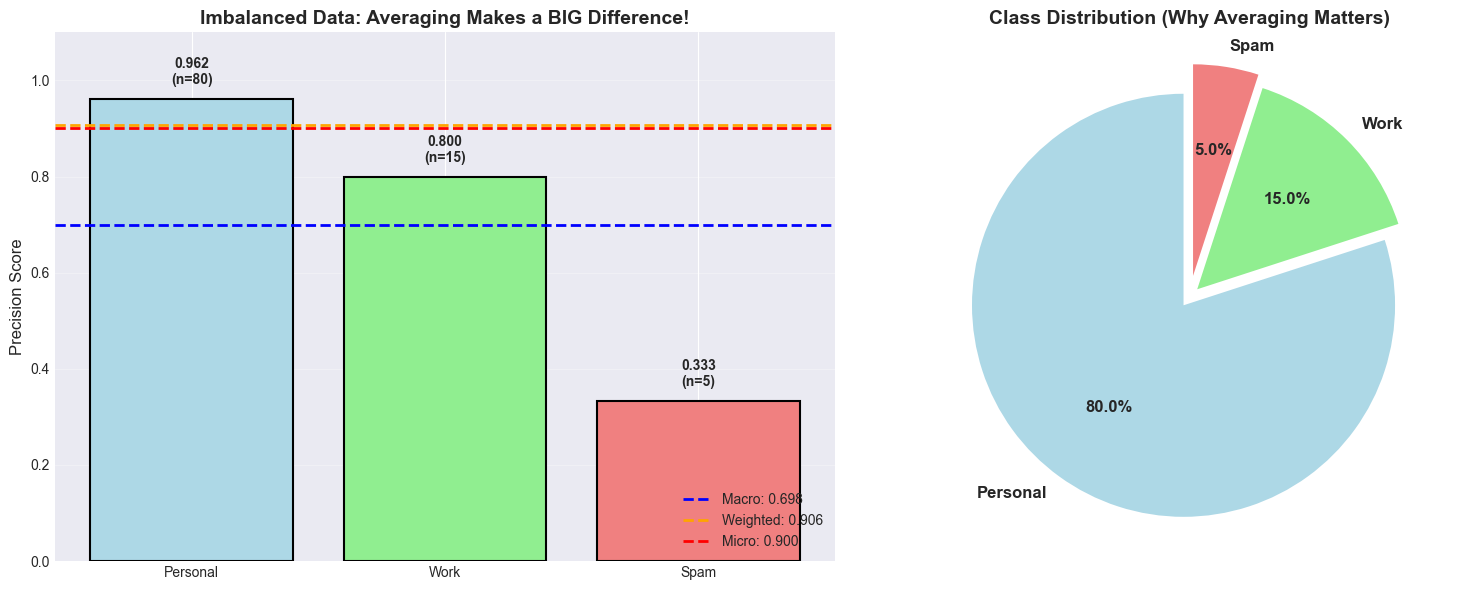

In [29]:
# Visualize the imbalanced case
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left: Per-class precision with support
x_pos = np.arange(len(imb_class_names))
colors_imb = ['lightblue', 'lightgreen', 'lightcoral']

bars = ax1.bar(x_pos, prec_per_class_imb, color=colors_imb, edgecolor='black', linewidth=1.5)
ax1.axhline(y=macro_imb, color='blue', linestyle='--', linewidth=2, label=f'Macro: {macro_imb:.3f}')
ax1.axhline(y=weighted_imb, color='orange', linestyle='--', linewidth=2, label=f'Weighted: {weighted_imb:.3f}')
ax1.axhline(y=micro_imb, color='red', linestyle='--', linewidth=2, label=f'Micro: {micro_imb:.3f}')

ax1.set_ylabel('Precision Score', fontsize=12)
ax1.set_title('Imbalanced Data: Averaging Makes a BIG Difference!', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(imb_class_names)
ax1.legend(loc='lower right')
ax1.set_ylim(0, 1.1)
ax1.grid(True, alpha=0.3, axis='y')

# Add support annotations
for i, (prec, supp) in enumerate(zip(prec_per_class_imb, support_imb)):
    ax1.text(i, prec + 0.03, f'{prec:.3f}\n(n={supp})', ha='center', fontsize=10, fontweight='bold')

# Right: Class distribution
ax2.pie(support_imb, labels=imb_class_names, autopct='%1.1f%%', colors=colors_imb,
        explode=(0.05, 0.05, 0.1), startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax2.set_title('Class Distribution (Why Averaging Matters)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Part 11.6: Hands-On Exercise - Multi-Class Metrics

Let's test your understanding! Here's a real-world scenario:

**Scenario**: Medical diagnosis system for 3 diseases (Common Cold, Flu, COVID-19)

Given this confusion matrix:
```
                Predicted: Cold  Predicted: Flu  Predicted: COVID
Actual: Cold           85              10               5
Actual: Flu            15              60              15  
Actual: COVID           5              10              85
```

**Your Tasks**:
1. Calculate precision, recall, and F1 for each class
2. Calculate macro, weighted, and micro averages
3. Which averaging method should the hospital prioritize, and why?

Try it yourself first, then check the solution below!

In [30]:
# SOLUTION - Run this after attempting yourself!

# Confusion matrix from the problem
cm_exercise = np.array([
    [85, 10, 5],   # Actual: Cold
    [15, 60, 15],  # Actual: Flu
    [5, 10, 85]    # Actual: COVID
])

disease_names = ['Cold', 'Flu', 'COVID']

# Recreate actual and predicted from confusion matrix (for sklearn verification)
y_true_exercise = []
y_pred_exercise = []
for actual_class in range(3):
    for pred_class in range(3):
        count = cm_exercise[actual_class, pred_class]
        y_true_exercise.extend([actual_class] * count)
        y_pred_exercise.extend([pred_class] * count)
y_true_exercise = np.array(y_true_exercise)
y_pred_exercise = np.array(y_pred_exercise)

print("SOLUTION")
print("="*70)
print("\n1. Per-Class Metrics:\n")

# Calculate per-class metrics manually
for class_idx, disease in enumerate(disease_names):
    tp = cm_exercise[class_idx, class_idx]
    fp = cm_exercise[:, class_idx].sum() - tp
    fn = cm_exercise[class_idx, :].sum() - tp
    tn = cm_exercise.sum() - tp - fp - fn
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    support = cm_exercise[class_idx, :].sum()
    
    print(f"{disease}:")
    print(f"  Precision: {tp}/{tp+fp} = {precision:.3f}")
    print(f"  Recall:    {tp}/{tp+fn} = {recall:.3f}")
    print(f"  F1 Score:  {f1:.3f}")
    print(f"  Support:   {support} patients\n")

# 2. Calculate averages
print("-"*70)
print("\n2. Averaging Methods:\n")

macro_prec = precision_score(y_true_exercise, y_pred_exercise, average='macro')
weighted_prec = precision_score(y_true_exercise, y_pred_exercise, average='weighted')
micro_prec = precision_score(y_true_exercise, y_pred_exercise, average='micro')

print(f"Macro Average Precision:    {macro_prec:.3f}")
print(f"Weighted Average Precision: {weighted_prec:.3f}")
print(f"Micro Average Precision:    {micro_prec:.3f}")

print("\n" + "-"*70)
print("\n3. Which averaging method should the hospital use?\n")

print("ANSWER: MACRO AVERAGE")
print("\nWhy?")
print("  ✓ All diseases are EQUALLY IMPORTANT to diagnose correctly")
print("  ✓ Missing COVID (even if rare) is just as bad as missing Cold")
print("  ✓ Macro average treats all classes equally, preventing bias toward common diseases")
print("\n  Weighted/Micro would prioritize Cold (most common) over COVID!")
print("  In healthcare, we can't afford to ignore rare but serious conditions.")
print("\n  However, the hospital should ALSO monitor per-class metrics")
print("  to ensure good performance on each disease individually.")

SOLUTION

1. Per-Class Metrics:

Cold:
  Precision: 85/105 = 0.810
  Recall:    85/100 = 0.850
  F1 Score:  0.829
  Support:   100 patients

Flu:
  Precision: 60/80 = 0.750
  Recall:    60/90 = 0.667
  F1 Score:  0.706
  Support:   90 patients

COVID:
  Precision: 85/105 = 0.810
  Recall:    85/100 = 0.850
  F1 Score:  0.829
  Support:   100 patients

----------------------------------------------------------------------

2. Averaging Methods:

Macro Average Precision:    0.790
Weighted Average Precision: 0.791
Micro Average Precision:    0.793

----------------------------------------------------------------------

3. Which averaging method should the hospital use?

ANSWER: MACRO AVERAGE

Why?
  ✓ All diseases are EQUALLY IMPORTANT to diagnose correctly
  ✓ Missing COVID (even if rare) is just as bad as missing Cold
  ✓ Macro average treats all classes equally, preventing bias toward common diseases

  Weighted/Micro would prioritize Cold (most common) over COVID!
  In healthcare, we 

### Averaging Strategies

For multi-class problems, we need to average metrics across classes:

- **Macro average**: Average metrics for each class (treats all classes equally)
- **Micro average**: Calculate metrics globally (treats all samples equally)
- **Weighted average**: Weight by class frequency (handles imbalance)

In [31]:
# Calculate metrics with different averaging
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_true_multi, y_pred_multi, target_names=class_names))

# Manual calculation for one class (Cat = class 0)
print("\n" + "="*60)
print("How to interpret 'macro avg' vs 'weighted avg':\n")

# Per-class metrics
prec_macro = precision_score(y_true_multi, y_pred_multi, average='macro')
prec_weighted = precision_score(y_true_multi, y_pred_multi, average='weighted')
prec_micro = precision_score(y_true_multi, y_pred_multi, average='micro')

print(f"Precision (macro):    {prec_macro:.2f} - Simple average across classes")
print(f"Precision (weighted): {prec_weighted:.2f} - Weighted by class frequency")
print(f"Precision (micro):    {prec_micro:.2f} - Global calculation (same as accuracy for multi-class)")

Classification Report:

              precision    recall  f1-score   support

         Cat       1.00      0.75      0.86         4
         Dog       0.67      0.67      0.67         3
        Bird       0.75      1.00      0.86         3

    accuracy                           0.80        10
   macro avg       0.81      0.81      0.79        10
weighted avg       0.82      0.80      0.80        10


How to interpret 'macro avg' vs 'weighted avg':

Precision (macro):    0.81 - Simple average across classes
Precision (weighted): 0.82 - Weighted by class frequency
Precision (micro):    0.80 - Global calculation (same as accuracy for multi-class)


## Part 12: Regression Metrics

Classification metrics (accuracy, F1, etc.) don't work for regression problems!

**Regression**: Predicting continuous values (e.g., house prices, temperature)

Let's look at common regression metrics:

In [32]:
# SOLUTION
print("SOLUTION TO R² EXERCISE")
print("="*70)

print("\n1. Which model has the 'best' R²?")
print("   → Model A with R² = 0.95")
print("   → It explains 95% of variance in house prices")

print("\n2. Which model makes the most accurate predictions on average?")
print("   → Model B with MAE = $15k")
print("   → On average, its predictions are off by only $15k")
print("   → Compare to Model A which is off by $50k!")

print("\n3. Which model should you choose?")
print("   → MODEL B!")
print("\n   Why? Because what matters is ACTUAL PREDICTION ERROR (MAE)")
print("   High R² doesn't guarantee low error - they measure different things:")
print("     - R²: How well you track variance (relative to mean)")
print("     - MAE: Average absolute error in predictions")

print("\n4. What might explain Model B's low R² but good MAE?")
print("   Possible explanations:")
print("   a) The data has LOW VARIANCE (houses have similar prices)")
print("      → Even small errors look bad relative to variance")
print("      → But absolute errors are still small!")
print("\n   b) The data has OUTLIERS that Model B ignores")
print("      → Model B makes consistent, accurate predictions")
print("      → But doesn't capture extreme variance (high/low outliers)")
print("      → This hurts R² but MAE stays good")

print("\n" + "="*70)
print("\n🔑 KEY LESSON:")
print("   Don't blindly trust R²! Always look at multiple metrics:")
print("   - R²: How well you explain variance")
print("   - MAE/RMSE: Actual prediction errors")
print("   - Visualizations: Do predictions make sense?")
print("\n   Context matters - choose metrics aligned with your goals!")

SOLUTION TO R² EXERCISE

1. Which model has the 'best' R²?
   → Model A with R² = 0.95
   → It explains 95% of variance in house prices

2. Which model makes the most accurate predictions on average?
   → Model B with MAE = $15k
   → On average, its predictions are off by only $15k
   → Compare to Model A which is off by $50k!

3. Which model should you choose?
   → MODEL B!

   Why? Because what matters is ACTUAL PREDICTION ERROR (MAE)
   High R² doesn't guarantee low error - they measure different things:
     - R²: How well you track variance (relative to mean)
     - MAE: Average absolute error in predictions

4. What might explain Model B's low R² but good MAE?
   Possible explanations:
   a) The data has LOW VARIANCE (houses have similar prices)
      → Even small errors look bad relative to variance
      → But absolute errors are still small!

   b) The data has OUTLIERS that Model B ignores
      → Model B makes consistent, accurate predictions
      → But doesn't capture extr

### Exercise: Understanding R²

**Scenario**: You're comparing 3 models for predicting house prices:

- **Model A**: R² = 0.95, MAE = $50k
- **Model B**: R² = 0.60, MAE = $15k  
- **Model C**: R² = 0.85, MAE = $30k

**Questions**:
1. Which model has the "best" R²?
2. Which model makes the most accurate predictions on average?
3. Which model should you choose?
4. What might explain Model B's low R² but good MAE?

Think about it, then check the solution!

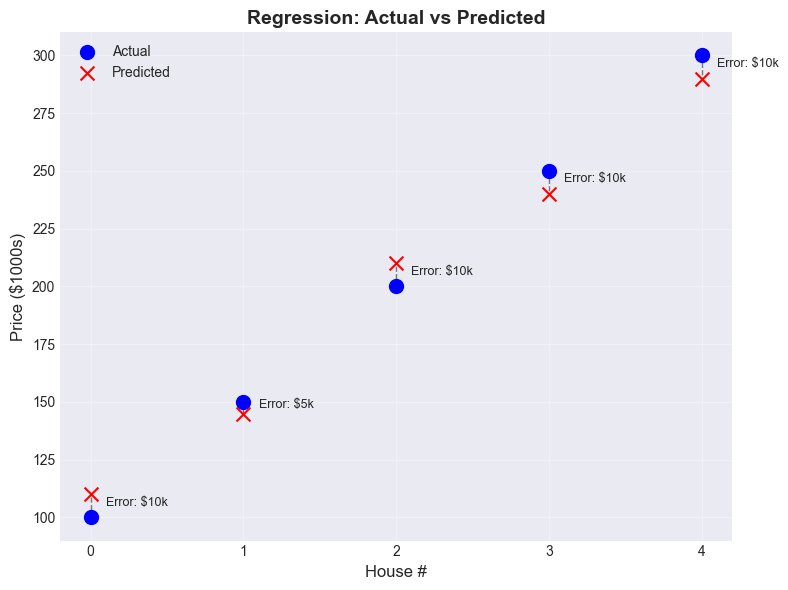

In [33]:
# Example: Predicting house prices (in thousands)
y_true_reg = np.array([100, 150, 200, 250, 300])  # Actual prices
y_pred_reg = np.array([110, 145, 210, 240, 290])  # Predicted prices

# Visualize
fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(y_true_reg))
ax.scatter(x, y_true_reg, s=100, color='blue', label='Actual', zorder=3)
ax.scatter(x, y_pred_reg, s=100, color='red', marker='x', label='Predicted', zorder=3)

# Draw lines showing errors
for i in range(len(x)):
    ax.plot([x[i], x[i]], [y_true_reg[i], y_pred_reg[i]], 
            'k--', alpha=0.5, linewidth=1)
    error = abs(y_true_reg[i] - y_pred_reg[i])
    ax.text(x[i] + 0.1, (y_true_reg[i] + y_pred_reg[i]) / 2, 
            f'Error: ${error}k', fontsize=9)

ax.set_xlabel('House #', fontsize=12)
ax.set_ylabel('Price ($1000s)', fontsize=12)
ax.set_title('Regression: Actual vs Predicted', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(x)

plt.tight_layout()
plt.show()

### MAE: Mean Absolute Error

**Most intuitive**: Average absolute difference between predictions and actual values.

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|$$

**Interpretation**: "On average, predictions are off by X units."

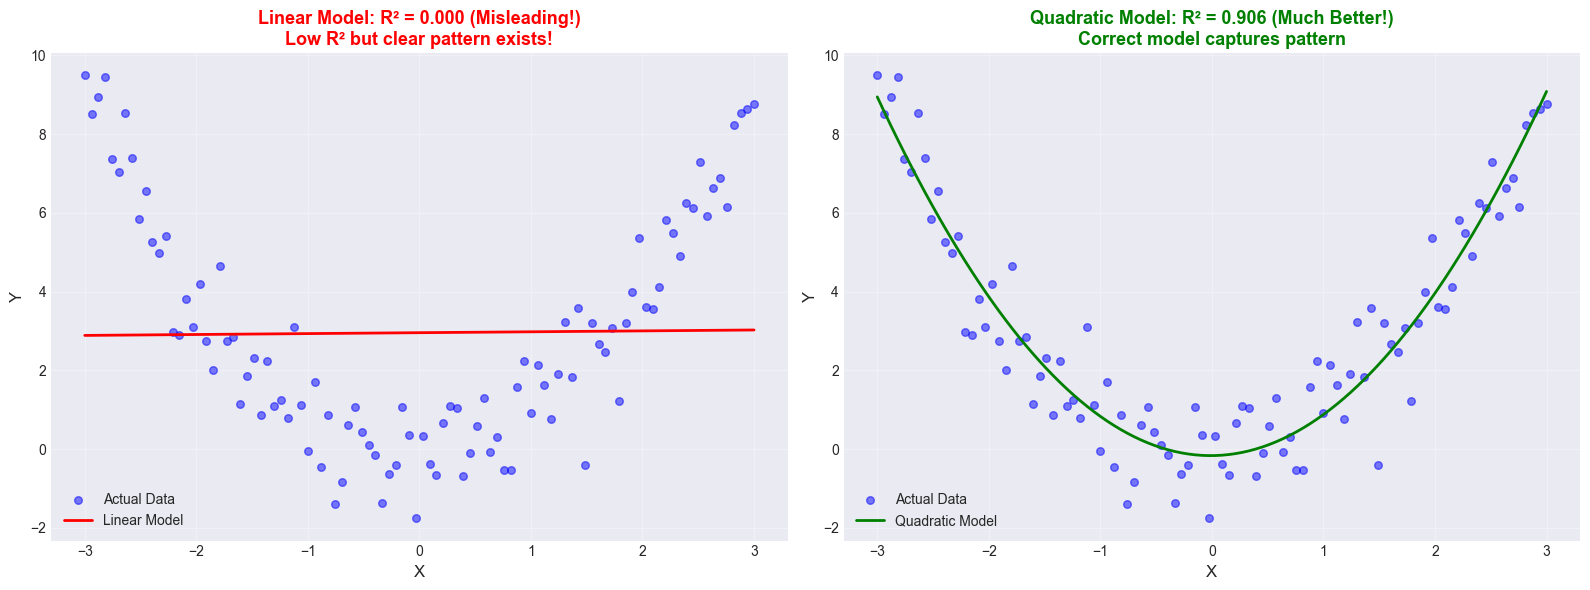

⚠️  KEY LESSON:
  - Linear model R²: 0.000 - Looks poor!
  - Quadratic model R²: 0.906 - Much better!

  → Low R² doesn't always mean 'no relationship'
  → It might mean you're using the WRONG MODEL
  → Always visualize your data before trusting R²!


In [34]:
# Example: Strong non-linear relationship but low R² with linear model
np.random.seed(42)
x_nonlinear = np.linspace(-3, 3, 100)
y_nonlinear = x_nonlinear ** 2 + np.random.normal(0, 1, 100)  # Quadratic relationship

# Fit linear model (wrong model!)
model_linear = LinearRegression()
model_linear.fit(x_nonlinear.reshape(-1, 1), y_nonlinear)
y_pred_linear = model_linear.predict(x_nonlinear.reshape(-1, 1))
r2_linear = r2_score(y_nonlinear, y_pred_linear)

# Fit quadratic model (correct model!)
poly_features = PolynomialFeatures(degree=2)
x_poly = poly_features.fit_transform(x_nonlinear.reshape(-1, 1))
model_poly = LinearRegression()
model_poly.fit(x_poly, y_nonlinear)
y_pred_poly = model_poly.predict(x_poly)
r2_poly = r2_score(y_nonlinear, y_pred_poly)

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Linear model (misleading low R²)
ax1.scatter(x_nonlinear, y_nonlinear, alpha=0.5, s=30, color='blue', label='Actual Data')
ax1.plot(x_nonlinear, y_pred_linear, 'r-', linewidth=2, label='Linear Model')
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_title(f'Linear Model: R² = {r2_linear:.3f} (Misleading!)\nLow R² but clear pattern exists!', 
              fontsize=13, fontweight='bold', color='red')
ax1.legend()
ax1.grid(True, alpha=0.3)

# RIGHT: Polynomial model (correct R²)
ax2.scatter(x_nonlinear, y_nonlinear, alpha=0.5, s=30, color='blue', label='Actual Data')
ax2.plot(x_nonlinear, y_pred_poly, 'g-', linewidth=2, label='Quadratic Model')
ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('Y', fontsize=12)
ax2.set_title(f'Quadratic Model: R² = {r2_poly:.3f} (Much Better!)\nCorrect model captures pattern', 
              fontsize=13, fontweight='bold', color='green')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("⚠️  KEY LESSON:")
print("  - Linear model R²: {:.3f} - Looks poor!".format(r2_linear))
print("  - Quadratic model R²: {:.3f} - Much better!".format(r2_poly))
print("\n  → Low R² doesn't always mean 'no relationship'")
print("  → It might mean you're using the WRONG MODEL")
print("  → Always visualize your data before trusting R²!")

### When R² Can Be Misleading

⚠️ **Important**: R² has limitations! Here's when to be careful:

1. **Non-linear relationships**: R² can be low even if there's a strong non-linear pattern
2. **Different scales**: R² values aren't comparable across different datasets
3. **Extrapolation**: High R² doesn't mean predictions outside training range will be good
4. **Overfitting**: Very high R² (>0.99) might indicate overfitting on small datasets

Let's see an example where R² is misleading:

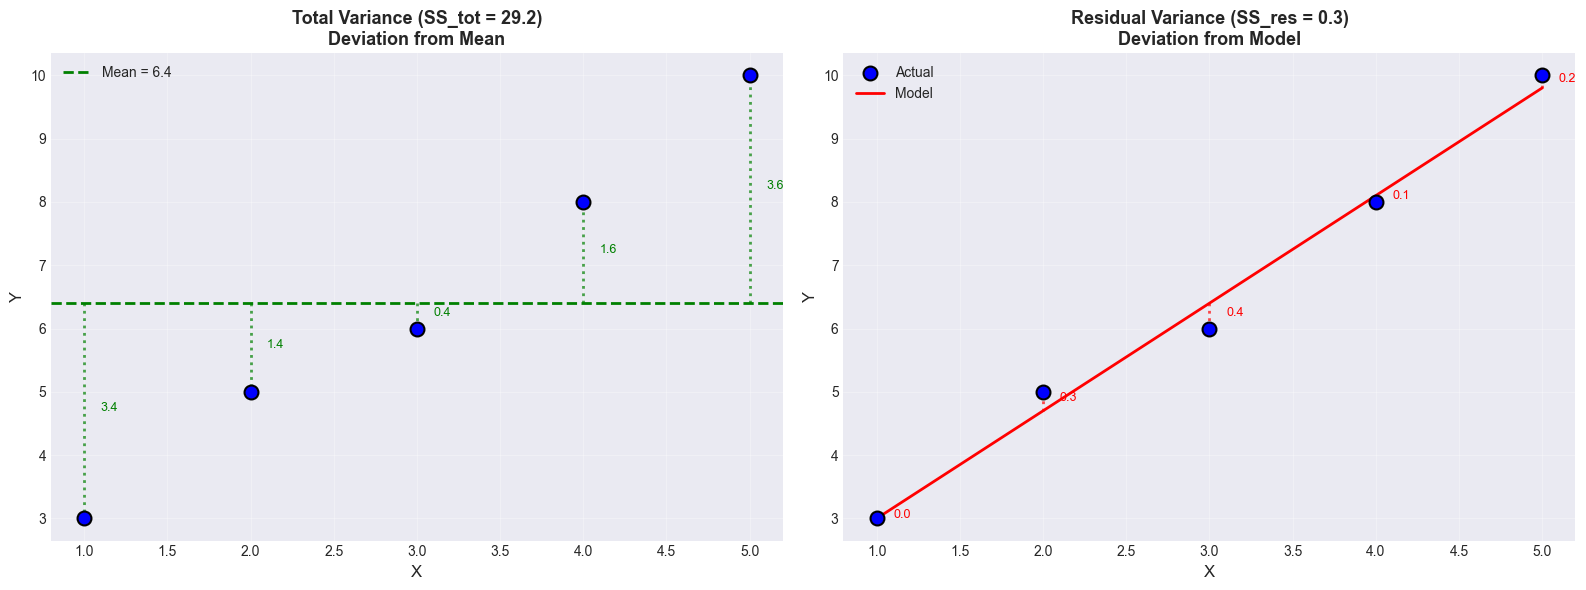


Variance Decomposition:
Total Variance (SS_tot):    29.20
Residual Variance (SS_res): 0.30
Explained Variance:         28.90

R² = 1 - (SS_res / SS_tot) = 1 - (0.30 / 29.20) = 0.990

Interpretation: Model explains 99.0% of variance!
                Model reduces error by 99.0% compared to just using the mean


In [35]:
# Visual demonstration of variance decomposition
# Use the "good" model from above
np.random.seed(42)
x_demo = np.array([1, 2, 3, 4, 5])
y_demo = np.array([3, 5, 6, 8, 10])

# Fit model
model_demo = LinearRegression()
model_demo.fit(x_demo.reshape(-1, 1), y_demo)
y_pred_demo = model_demo.predict(x_demo.reshape(-1, 1))
y_mean_demo = np.mean(y_demo)

# Calculate components
ss_tot = np.sum((y_demo - y_mean_demo) ** 2)
ss_res = np.sum((y_demo - y_pred_demo) ** 2)
r2_demo = 1 - (ss_res / ss_tot)

# Create visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Show total variance (from mean)
ax1.scatter(x_demo, y_demo, s=100, color='blue', zorder=3, edgecolor='black', linewidth=1.5)
ax1.axhline(y=y_mean_demo, color='green', linestyle='--', linewidth=2, label=f'Mean = {y_mean_demo:.1f}')

# Draw vertical lines from mean to points (total variance)
for i in range(len(x_demo)):
    ax1.plot([x_demo[i], x_demo[i]], [y_mean_demo, y_demo[i]], 'g:', linewidth=2, alpha=0.7)
    mid_y = (y_mean_demo + y_demo[i]) / 2
    ax1.text(x_demo[i] + 0.1, mid_y, f'{abs(y_demo[i] - y_mean_demo):.1f}', fontsize=9, color='green')

ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_title(f'Total Variance (SS_tot = {ss_tot:.1f})\nDeviation from Mean', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# RIGHT: Show residual variance (after model)
ax2.scatter(x_demo, y_demo, s=100, color='blue', zorder=3, edgecolor='black', linewidth=1.5, label='Actual')
ax2.plot(x_demo, y_pred_demo, 'r-', linewidth=2, label='Model')

# Draw vertical lines from predictions to actual (residual variance)
for i in range(len(x_demo)):
    ax2.plot([x_demo[i], x_demo[i]], [y_pred_demo[i], y_demo[i]], 'r:', linewidth=2, alpha=0.7)
    mid_y = (y_pred_demo[i] + y_demo[i]) / 2
    ax2.text(x_demo[i] + 0.1, mid_y, f'{abs(y_demo[i] - y_pred_demo[i]):.1f}', fontsize=9, color='red')

ax2.set_xlabel('X', fontsize=12)
ax2.set_ylabel('Y', fontsize=12)
ax2.set_title(f'Residual Variance (SS_res = {ss_res:.1f})\nDeviation from Model', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nVariance Decomposition:")
print("="*70)
print(f"Total Variance (SS_tot):    {ss_tot:.2f}")
print(f"Residual Variance (SS_res): {ss_res:.2f}")
print(f"Explained Variance:         {ss_tot - ss_res:.2f}")
print(f"\nR² = 1 - (SS_res / SS_tot) = 1 - ({ss_res:.2f} / {ss_tot:.2f}) = {r2_demo:.3f}")
print(f"\nInterpretation: Model explains {r2_demo*100:.1f}% of variance!")
print(f"                Model reduces error by {(1-ss_res/ss_tot)*100:.1f}% compared to just using the mean")

### What Does "Variance Explained" Actually Mean?

Let's break down the formula visually:

$$R^2 = 1 - \frac{\text{Sum of Squared Residuals (SS\\_res)}}{\text{Total Sum of Squares (SS\\_tot)}}$$

- **SS_tot**: How much variance exists in the data (from the mean)
- **SS_res**: How much variance remains after our model makes predictions
- **R²**: Fraction of variance our model "explained" or "captured"

Think of it like this:
- **SS_tot = 100**: The data has 100 "units" of variance to explain
- **SS_res = 20**: After our model, 20 units remain unexplained
- **R² = 1 - 20/100 = 0.80**: We explained 80% of the variance!

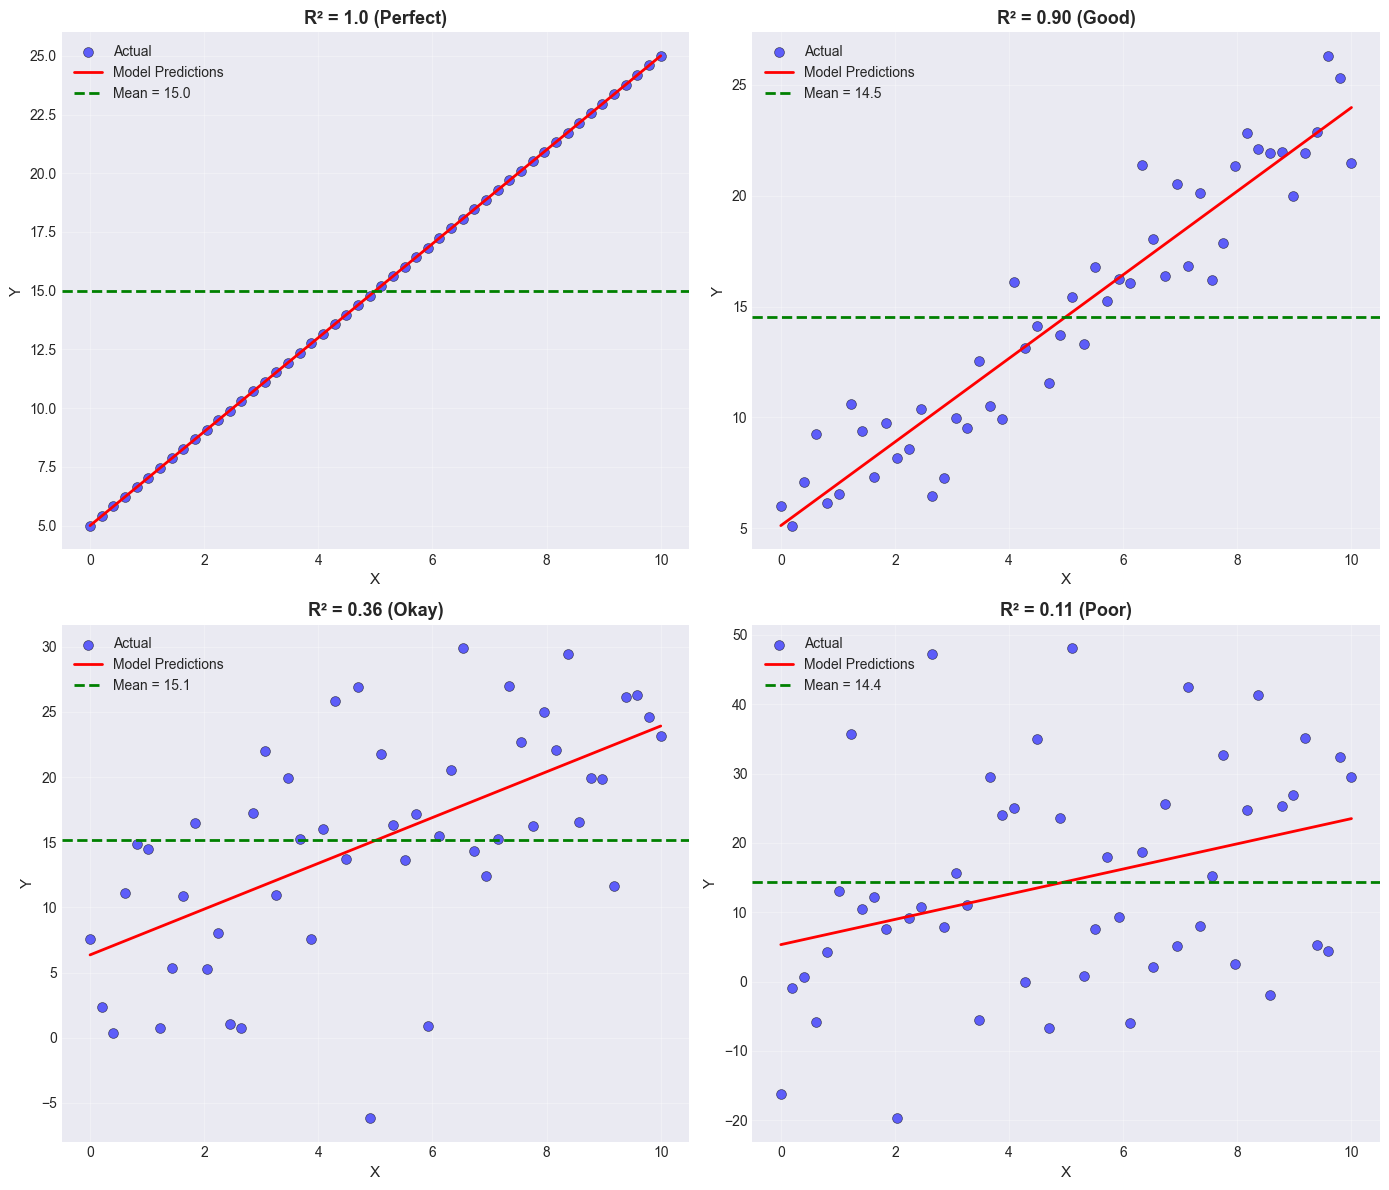


Key Observations:
  - R² = 1.0: All points perfectly on the line
  - R² ≈ 0.9: Points close to line, good predictions
  - R² ≈ 0.5: Noticeable scatter, moderate predictions
  - R² ≈ 0.1: Lots of scatter, barely better than mean


In [36]:
# Generate data with different R² values
np.random.seed(42)
n = 50
x = np.linspace(0, 10, n)

# Create datasets with different noise levels
y_perfect = 2 * x + 5  # Perfect linear relationship
y_good = y_perfect + np.random.normal(0, 2, n)  # Some noise (R² ≈ 0.9)
y_okay = y_perfect + np.random.normal(0, 8, n)  # More noise (R² ≈ 0.5)
y_poor = y_perfect + np.random.normal(0, 15, n)  # Lots of noise (R² ≈ 0.1)

# Predictions (simple linear fit)

def fit_and_predict(x, y):
    model = LinearRegression()
    model.fit(x.reshape(-1, 1), y)
    y_pred = model.predict(x.reshape(-1, 1))
    r2 = r2_score(y, y_pred)
    return y_pred, r2

y_pred_perfect, r2_perfect = fit_and_predict(x, y_perfect)
y_pred_good, r2_good = fit_and_predict(x, y_good)
y_pred_okay, r2_okay = fit_and_predict(x, y_okay)
y_pred_poor, r2_poor = fit_and_predict(x, y_poor)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
datasets = [
    (y_perfect, y_pred_perfect, r2_perfect, "R² = 1.0 (Perfect)", axes[0, 0]),
    (y_good, y_pred_good, r2_good, f"R² = {r2_good:.2f} (Good)", axes[0, 1]),
    (y_okay, y_pred_okay, r2_okay, f"R² = {r2_okay:.2f} (Okay)", axes[1, 0]),
    (y_poor, y_pred_poor, r2_poor, f"R² = {r2_poor:.2f} (Poor)", axes[1, 1]),
]

for y_actual, y_pred, r2, title, ax in datasets:
    # Plot actual data points
    ax.scatter(x, y_actual, alpha=0.6, s=50, color='blue', label='Actual', edgecolor='black', linewidth=0.5)
    
    # Plot prediction line
    ax.plot(x, y_pred, 'r-', linewidth=2, label='Model Predictions')
    
    # Plot mean line (baseline)
    y_mean = np.mean(y_actual)
    ax.axhline(y=y_mean, color='green', linestyle='--', linewidth=2, label=f'Mean = {y_mean:.1f}')
    
    # Styling
    ax.set_xlabel('X', fontsize=11)
    ax.set_ylabel('Y', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("  - R² = 1.0: All points perfectly on the line")
print("  - R² ≈ 0.9: Points close to line, good predictions")
print("  - R² ≈ 0.5: Noticeable scatter, moderate predictions")
print("  - R² ≈ 0.1: Lots of scatter, barely better than mean")

### Understanding R² Intuitively

R² (R-squared) is often misunderstood. Let's build intuition step-by-step!

**The Core Question**: How much better is your model than just predicting the mean?

**The Scale**:
- **R² = 1.0**: Perfect predictions (all points on the line)
- **R² = 0.5**: Explains 50% of variance (decent, but room to improve)
- **R² = 0.0**: No better than predicting the mean (useless!)
- **R² < 0**: Worse than predicting the mean (catastrophically bad!)

Let's visualize what different R² values look like:

In [37]:
# Calculate MAE
errors = np.abs(y_true_reg - y_pred_reg)
mae_manual = np.mean(errors)

print("MAE Calculation:\n")
print(f"Errors: {errors}")
print(f"Average: {mae_manual:.1f}")
print(f"\nInterpretation: Predictions are off by ${mae_manual:.1f}k on average")

# Using sklearn
mae_sklearn = mean_absolute_error(y_true_reg, y_pred_reg)
print(f"\nMAE (sklearn): {mae_sklearn:.1f}")

MAE Calculation:

Errors: [10  5 10 10 10]
Average: 9.0

Interpretation: Predictions are off by $9.0k on average

MAE (sklearn): 9.0


### MSE: Mean Squared Error

**Penalizes large errors**: Squares the differences, so large errors are weighted more.

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2$$

**Use when**: Large errors are much worse than small errors.

In [38]:
# Calculate MSE
squared_errors = (y_true_reg - y_pred_reg) ** 2
mse_manual = np.mean(squared_errors)

print("MSE Calculation:\n")
print(f"Errors: {y_true_reg - y_pred_reg}")
print(f"Squared Errors: {squared_errors}")
print(f"Average: {mse_manual:.1f}")

# Using sklearn
mse_sklearn = mean_squared_error(y_true_reg, y_pred_reg)
print(f"\nMSE (sklearn): {mse_sklearn:.1f}")

print(f"\nNote: MSE is in squared units, making it harder to interpret directly.")

MSE Calculation:

Errors: [-10   5 -10  10  10]
Squared Errors: [100  25 100 100 100]
Average: 85.0

MSE (sklearn): 85.0

Note: MSE is in squared units, making it harder to interpret directly.


### RMSE: Root Mean Squared Error

**Same units as target**: Take the square root of MSE.

$$\text{RMSE} = \sqrt{\text{MSE}}$$

**Best of both worlds**: Penalizes large errors (like MSE) but interpretable (like MAE).

In [39]:
# Calculate RMSE
rmse = np.sqrt(mse_manual)

print(f"RMSE = √MSE = √{mse_manual:.1f} = {rmse:.1f}")
print(f"\nInterpretation: Similar to MAE, but penalizes large errors more.")

RMSE = √MSE = √85.0 = 9.2

Interpretation: Similar to MAE, but penalizes large errors more.


### R²: Coefficient of Determination

**"How much variance does my model explain?"**

$$R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$

- **R² = 1**: Perfect predictions
- **R² = 0**: Model is no better than predicting the mean
- **R² < 0**: Model is worse than predicting the mean!

In [40]:
# Calculate R²
y_mean = np.mean(y_true_reg)
ss_res = np.sum((y_true_reg - y_pred_reg) ** 2)  # Residual sum of squares
ss_tot = np.sum((y_true_reg - y_mean) ** 2)      # Total sum of squares
r2_manual = 1 - (ss_res / ss_tot)

print(f"R² Calculation:\n")
print(f"Mean of actual values: ${y_mean:.1f}k")
print(f"Residual sum of squares (SS_res): {ss_res:.1f}")
print(f"Total sum of squares (SS_tot): {ss_tot:.1f}")
print(f"\nR² = 1 - (SS_res / SS_tot) = 1 - ({ss_res:.1f} / {ss_tot:.1f}) = {r2_manual:.3f}")

# Using sklearn
r2_sklearn = r2_score(y_true_reg, y_pred_reg)
print(f"\nR² (sklearn): {r2_sklearn:.3f}")
print(f"\nInterpretation: Model explains {r2_sklearn*100:.1f}% of variance in the data")

R² Calculation:

Mean of actual values: $200.0k
Residual sum of squares (SS_res): 425.0
Total sum of squares (SS_tot): 25000.0

R² = 1 - (SS_res / SS_tot) = 1 - (425.0 / 25000.0) = 0.983

R² (sklearn): 0.983

Interpretation: Model explains 98.3% of variance in the data


### Comparing Regression Metrics

In [41]:
# Summary table
metrics_summary = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Value': [
        f'${mae_manual:.1f}k',
        f'{mse_manual:.1f}',
        f'${rmse:.1f}k',
        f'{r2_manual:.3f}'
    ],
    'Interpretation': [
        'Average error',
        'Penalizes large errors (squared units)',
        'Like MAE but penalizes large errors',
        'Variance explained (0 to 1)'
    ]
})

print("\nRegression Metrics Summary:\n")
print(metrics_summary.to_string(index=False))


Regression Metrics Summary:

Metric Value                         Interpretation
   MAE $9.0k                          Average error
   MSE  85.0 Penalizes large errors (squared units)
  RMSE $9.2k    Like MAE but penalizes large errors
    R² 0.983            Variance explained (0 to 1)


## Part 13: Practical Guidelines - Which Metric to Use?

Here's a decision tree to help you choose the right metric:

In [42]:
from IPython.display import Markdown

decision_tree = """
### Classification Metrics Decision Tree

```
Is your dataset balanced?
│
├─ YES → Use Accuracy (simple and interpretable)
│
└─ NO → Are false positives and false negatives equally bad?
    │
    ├─ YES → Use F1 Score (balances precision and recall)
    │
    └─ NO → Which is worse?
        │
        ├─ False Negatives (missing positives) → Use Recall
        │   Examples: Medical diagnosis, fraud detection
        │
        └─ False Positives (false alarms) → Use Precision
            Examples: Spam filters, recommendations
```

### Regression Metrics Decision Tree

```
Do you want to penalize large errors more?
│
├─ NO → Use MAE (most interpretable)
│
└─ YES → Use RMSE (or MSE for optimization)

Want to know % of variance explained?
└─ Use R²
```
"""

display(Markdown(decision_tree))


### Classification Metrics Decision Tree

```
Is your dataset balanced?
│
├─ YES → Use Accuracy (simple and interpretable)
│
└─ NO → Are false positives and false negatives equally bad?
    │
    ├─ YES → Use F1 Score (balances precision and recall)
    │
    └─ NO → Which is worse?
        │
        ├─ False Negatives (missing positives) → Use Recall
        │   Examples: Medical diagnosis, fraud detection
        │
        └─ False Positives (false alarms) → Use Precision
            Examples: Spam filters, recommendations
```

### Regression Metrics Decision Tree

```
Do you want to penalize large errors more?
│
├─ NO → Use MAE (most interpretable)
│
└─ YES → Use RMSE (or MSE for optimization)

Want to know % of variance explained?
└─ Use R²
```


### Common Pitfalls

1. **Metric Shopping**: Don't keep trying different metrics until you find one that makes your model look good!

2. **Ignoring Imbalance**: Don't use accuracy on imbalanced datasets.

3. **Confusing Loss and Metrics**: Remember - optimize loss, evaluate with metrics.

4. **Single Metric Obsession**: Always report multiple metrics to get a full picture.

5. **Forgetting Context**: The "best" metric depends on your application!

### Best Practices

1. **Report multiple metrics**: Don't rely on just one number
2. **Include confusion matrix**: Shows exactly where errors occur
3. **Consider class distribution**: Mention if dataset is imbalanced
4. **Think about costs**: What's worse - false positives or false negatives?
5. **Use appropriate baselines**: Compare against simple baselines (e.g., always predicting majority class)

## Part 14: Hands-On Exercise

Now it's your turn! Let's practice calculating metrics.

**Scenario**: You've built a model to detect fraudulent transactions.

Given this confusion matrix:

```
                Predicted: Legit  Predicted: Fraud
Actual: Legit        950              50
Actual: Fraud         15              85
```

In [43]:
# Given confusion matrix values
tn_ex = 950  # True Negatives (correctly identified legit)
fp_ex = 50   # False Positives (legit flagged as fraud)
fn_ex = 15   # False Negatives (fraud missed)
tp_ex = 85   # True Positives (correctly identified fraud)

print("Exercise: Calculate the following metrics by hand, then check your answers!\n")
print("Given:")
print(f"  TN = {tn_ex} (correctly identified legit)")
print(f"  FP = {fp_ex} (legit flagged as fraud)")
print(f"  FN = {fn_ex} (fraud missed)")
print(f"  TP = {tp_ex} (correctly identified fraud)")
print("\nCalculate:")
print("  1. Accuracy")
print("  2. Precision")
print("  3. Recall")
print("  4. F1 Score")
print("\nTry calculating these yourself, then run the next cell for answers!")

Exercise: Calculate the following metrics by hand, then check your answers!

Given:
  TN = 950 (correctly identified legit)
  FP = 50 (legit flagged as fraud)
  FN = 15 (fraud missed)
  TP = 85 (correctly identified fraud)

Calculate:
  1. Accuracy
  2. Precision
  3. Recall
  4. F1 Score

Try calculating these yourself, then run the next cell for answers!


**Your work area**: Try calculating the metrics here (on paper or in your head), then proceed to see the solutions.

In [44]:
# Solution
print("SOLUTIONS:\n")
print("="*60)

# 1. Accuracy
acc_ex = (tp_ex + tn_ex) / (tp_ex + tn_ex + fp_ex + fn_ex)
print("\n1. Accuracy:")
print(f"   Formula: (TP + TN) / (TP + TN + FP + FN)")
print(f"   Calculation: ({tp_ex} + {tn_ex}) / ({tp_ex} + {tn_ex} + {fp_ex} + {fn_ex})")
print(f"   Result: {acc_ex:.3f} or {acc_ex*100:.1f}%")

# 2. Precision
prec_ex = tp_ex / (tp_ex + fp_ex)
print("\n2. Precision:")
print(f"   Formula: TP / (TP + FP)")
print(f"   Calculation: {tp_ex} / ({tp_ex} + {fp_ex})")
print(f"   Result: {prec_ex:.3f} or {prec_ex*100:.1f}%")
print(f"   Meaning: {prec_ex*100:.1f}% of fraud predictions were correct")

# 3. Recall
rec_ex = tp_ex / (tp_ex + fn_ex)
print("\n3. Recall:")
print(f"   Formula: TP / (TP + FN)")
print(f"   Calculation: {tp_ex} / ({tp_ex} + {fn_ex})")
print(f"   Result: {rec_ex:.3f} or {rec_ex*100:.1f}%")
print(f"   Meaning: We caught {rec_ex*100:.1f}% of all actual fraud cases")

# 4. F1 Score
f1_ex = 2 * (prec_ex * rec_ex) / (prec_ex + rec_ex)
print("\n4. F1 Score:")
print(f"   Formula: 2 * (Precision * Recall) / (Precision + Recall)")
print(f"   Calculation: 2 * ({prec_ex:.3f} * {rec_ex:.3f}) / ({prec_ex:.3f} + {rec_ex:.3f})")
print(f"   Result: {f1_ex:.3f}")

print("\n" + "="*60)
print("\nBONUS QUESTION: Which metric should you prioritize for fraud detection?")
print("\nThink about it, then run the next cell...")

SOLUTIONS:


1. Accuracy:
   Formula: (TP + TN) / (TP + TN + FP + FN)
   Calculation: (85 + 950) / (85 + 950 + 50 + 15)
   Result: 0.941 or 94.1%

2. Precision:
   Formula: TP / (TP + FP)
   Calculation: 85 / (85 + 50)
   Result: 0.630 or 63.0%
   Meaning: 63.0% of fraud predictions were correct

3. Recall:
   Formula: TP / (TP + FN)
   Calculation: 85 / (85 + 15)
   Result: 0.850 or 85.0%
   Meaning: We caught 85.0% of all actual fraud cases

4. F1 Score:
   Formula: 2 * (Precision * Recall) / (Precision + Recall)
   Calculation: 2 * (0.630 * 0.850) / (0.630 + 0.850)
   Result: 0.723


BONUS QUESTION: Which metric should you prioritize for fraud detection?

Think about it, then run the next cell...


Display the output.

In [45]:
print("BONUS ANSWER: RECALL!")
print("\nWhy?")
print("- False Negative (FN): Missing fraud = Money lost!")
print("- False Positive (FP): Flagging legit transaction = Minor inconvenience")
print("\nFor fraud detection, it's better to be safe than sorry.")
print("We'd rather investigate a few extra transactions than miss actual fraud.")

BONUS ANSWER: RECALL!

Why?
- False Negative (FN): Missing fraud = Money lost!
- False Positive (FP): Flagging legit transaction = Minor inconvenience

For fraud detection, it's better to be safe than sorry.
We'd rather investigate a few extra transactions than miss actual fraud.


## Part 15: Summary & Next Steps

Congratulations! You now understand machine learning metrics.

### Key Takeaways

1. **Metrics measure model performance** - They tell us how good our model is

2. **Confusion Matrix is the foundation** - All classification metrics come from TP, TN, FP, FN

3. **Different metrics for different needs**:
   - **Accuracy**: Good for balanced datasets
   - **Precision**: Minimize false positives
   - **Recall**: Minimize false negatives
   - **F1**: Balance precision and recall

4. **Loss vs Metrics**:
   - **Loss**: Differentiable, used for training
   - **Metrics**: Interpretable, used for evaluation

5. **Context matters** - The "best" metric depends on your application!

6. **Report multiple metrics** - Don't rely on just one number

### Quick Reference Table

In [46]:
quick_ref = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1', 'MAE', 'MSE', 'RMSE', 'R²'],
    'Formula': [
        '(TP+TN)/(TP+TN+FP+FN)',
        'TP/(TP+FP)',
        'TP/(TP+FN)',
        '2×P×R/(P+R)',
        'mean(|y-ŷ|)',
        'mean((y-ŷ)²)',
        '√MSE',
        '1 - SS_res/SS_tot'
    ],
    'Question Answered': [
        'What % correct?',
        'When I say yes, am I right?',
        'Did I find all positives?',
        'Balance P and R?',
        'Average error?',
        'Penalize large errors?',
        'Like MAE but penalize large?',
        'Variance explained?'
    ],
    'Use For': [
        'Balanced classes',
        'Avoid false alarms',
        'Catch all positives',
        'Imbalanced data',
        'Regression (intuitive)',
        'Training regression',
        'Regression (interpretable)',
        'Model comparison'
    ]
})

print("\nQUICK REFERENCE - ML METRICS CHEAT SHEET\n")
print(quick_ref.to_string(index=False))


QUICK REFERENCE - ML METRICS CHEAT SHEET

   Metric               Formula            Question Answered                    Use For
 Accuracy (TP+TN)/(TP+TN+FP+FN)              What % correct?           Balanced classes
Precision            TP/(TP+FP)  When I say yes, am I right?         Avoid false alarms
   Recall            TP/(TP+FN)    Did I find all positives?        Catch all positives
       F1           2×P×R/(P+R)             Balance P and R?            Imbalanced data
      MAE           mean(|y-ŷ|)               Average error?     Regression (intuitive)
      MSE          mean((y-ŷ)²)       Penalize large errors?        Training regression
     RMSE                  √MSE Like MAE but penalize large? Regression (interpretable)
       R²     1 - SS_res/SS_tot          Variance explained?           Model comparison


### Reflection Questions

Test your understanding:

1. **Why is accuracy misleading for imbalanced datasets?**
   - Hint: Think about the 99% accuracy cancer detector

2. **When would you prioritize recall over precision?**
   - Hint: What's worse - false negatives or false positives?

3. **Why can't we use accuracy as a loss function?**
   - Hint: Think about gradients

4. **What's the difference between MAE and RMSE?**
   - Hint: Think about outliers

### Further Learning

Ready to dive deeper? Explore:

- **ROC Curves and AUC**: Visualizing performance across all thresholds
- **Precision-Recall Curves**: Alternative to ROC for imbalanced data
- **Multi-label Classification**: Metrics for problems with multiple labels per sample
- **Custom Metrics**: Creating domain-specific metrics
- **Statistical Significance**: Are metric differences meaningful?

**Practice Projects**:
1. Build a spam classifier and compare metrics
2. Try different classification thresholds and observe the precision-recall tradeoff
3. Compare regression models using different metrics

### Final Thoughts

Remember:
- Metrics are tools, not goals
- Always consider the real-world impact
- No single metric tells the whole story
- Choose metrics that align with your business objectives

**Happy modeling!**